# Lab 2 : Training Deep Learning Models
## Polytech Paris-Saclay : Machine Learning II
### Name : Marko BABIC


___
## Goals
___

The goal of this practical work is to build a simple neural network and to become familiar with these models and how to train them with the backpropagation of the gradient.

To do this, we will begin by theoretically studying a perceptron with a hidden layer and its learning procedure.

We will then implement this network with the PyTorch library first on a toy problem to check that it is working correctly, then on the MNIST dataset.

___
## Section 1 - Theoretical foundation
___

In supervised learning, to apply a neural network to a machine learning problem, we need 4 elements :

*   A supervised dataset = data with annoted labels
*   A network architecture = different type of output layer, hidden layers, input layers
*   A loss function that we will optimize the model.
*   An optimization algorithm to minimize the loss function.


### 1.1 Supervised dataset

We are interested in a supervised classification task. Thus, we have access to a supervised dataset made of N (features, targets) pairs.

This supervised dataset is split into several sets: **train**, **test** and if possible **val**.

**1. What are the train, val and test sets used for?**

**Training Set:** Data used to compute gradients and update the model's weights and biases during the training process => To train the model.

**Validation Set:** Data used for model selection and hyperparameter tuning (e.g., learning rate, number of layers, or hidden units) to ensure the model generalizes well to unseen data.

**Test Set:** Data used only at the very end to estimate the generalization performance on completely unseen examples.

**2. What is the influence of the number of examples N?**

The number of training examples N has a significant influence on the model's **accuracy**, **training speed**, and its **ability to generalize**.

1. Example of influence on Accuracy

    Smaller N: With very few examples, the model may perfectly memorize the training data (low training error) but fail to represent the actual data distribution, leading to a high gap between training and test error.

2. Example of influence on Training Speed

    Gradient Descent (GD): In standard GD, the gradient is calculated by averaging the loss over all N examples. As N increases, each update step becomes computationally expensive and slow.

3. Example of influence on the ability to generalize

    Overfitting: Consider a model trained to classify whether a patient has cancer (binary classification).
    
    If the number of training examples (N) is too low, the model may 'memorize' the specific training data rather than learning general patterns. As a result, it will fail to generalize to new, unseen patients, leading to poor accuracy on the test set.

### 1.2 Network architcture (forward)

A neural network f is a succession of mathematical transformations allowing to pass from the space of features to the space of predictions:

We consider a Multi-Layer Perceptron (MLP) with one hidden layer.
The architecture can be defined mathematically as follows:

**1) Input:** Let $x \in \mathbb{R}^{d_{in}}$ be the input vector, where $d_{in}$ is the number of input features.

**2) Hidden Layer:**
The input is transformed by a linear layer followed by a non-linear activation function $\phi$ (e.g., ReLU or Sigmoid):
$$
a^{(1)} = W^{(1)}x + b^{(1)}
$$
$$
h^{(1)} = \phi(a^{(1)})
$$
Where:
* $W^{(1)} \in \mathbb{R}^{d_{hidden} \times d_{in}}$ is the weight matrix of the hidden layer.
* $b^{(1)} \in \mathbb{R}^{d_{hidden}}$ is the bias vector.
* $h^{(1)} \in \mathbb{R}^{d_{hidden}}$ is the hidden representation.

**3) Output Layer:**
The hidden representation is mapped to the output score (logits) via a second linear transformation:
$$
z = W^{(2)}h^{(1)} + b^{(2)}
$$
Where:
* $W^{(2)} \in \mathbb{R}^{d_{out} \times d_{hidden}}$ is the weight matrix of the output layer.
* $b^{(2)} \in \mathbb{R}^{d_{out}}$ is the bias vector.

#### Questions

**3. Why is it important to add activation functions between linear transformations ?**

If we do not include non-linear activation functions, the entire neural network collapses into a simple linear model.
Mathematically, the composition of two linear transformations is also a linear transformation:
$$
W_2(W_1 x + b_1) + b_2 = (W_2 W_1)x + (W_2 b_1 + b_2) = W'x + b'
$$
By introducing non-linearities (like $\tanh$ or ReLU), we enable the network to approximate any continuous function and separate data that is not linearly separable.

**4. What are the sizes nx, nh, ny in the figure 1? In practice, how are these sizes chosen?**

These values represent the **dimensions** (width) of the vector at each stage, not the number of layers.

* **$n_x$ (Input Dimension):** Fixed by the dataset.
    * *Example:* If input images are $28 \times 28$ pixels, then $n_x = 784$.
* **$n_y$ (Output Dimension):** Fixed by the task.
    * *Example:* For a classification task with 10 classes (like MNIST), $n_y = 10$.
* **$n_h$ (Hidden Dimension):** A **hyperparameter** chosen by the us.
    * It determines the model'complexity

**5. What do the vectors $\hat{y}$ and y represent? What is the difference between these two quantities?**

* **$\hat{y}$ (Predicted Output):**
  The vector produced by the neural network after the activation function (e.g., Softmax). It contains the **estimated probabilities** for each class.
  $$\hat{y} = f(x; W, b)$$

* **$y$ (Ground Truth):**
  The true label vector from the dataset. In a classification task with $C$ classes, it is typically a **one-hot encoded vector** (zeros everywhere except for a $1$ at the correct class index).

**Difference:**
* **$\hat{y}$** is the model's **estimation**.
* **$y$** is the **reality** (target).

**6. Why use a SoftMax function as the output activation function ?**

We use the **SoftMax** function because it transforms the raw output into a valid **probability distribution**.
It squashes each output value between 0 and 1. Moreover, the sum of all outputs equals 1.

**7. Write the mathematical equations allowing to perform the forward pass of the neural network, i.e. allowing to successively produce  $\tilde{h}$ , h,  $\tilde{y}$ , and $\hat{y}$ starting at x**

#### In our Lab,

**Input:** $x \in \mathbb{R}^{n_x}$

**Hidden Layer (size $n_h$):**
$$
\tilde{h} = W_h x + b_h
$$
$$
h = \tanh(\tilde{h})
$$
*Where $W_h \in \mathbb{R}^{n_h \times n_x}$ and $b_h \in \mathbb{R}^{n_h}$.*

**Output Layer (size $n_y$):**
$$
\tilde{y} = W_y h + b_y
$$
$$
\hat{y} = \text{Softmax}(\tilde{y})
$$
*Where $W_y \in \mathbb{R}^{n_y \times n_h}$ and $b_y \in \mathbb{R}^{n_y}$.*

### 1.3 Loss function

Thanks to the forward pass, our neural network produces for the input x(i) an output $\hat{y}$(i) . We would like
to know how much this output differs from the target y(i). For that, we use a loss function adapted to
our problem. Most of the time, the global loss function L(X, Y ) is the average of a unit loss function
between predictions and targets:

**Global Cost Function** :
The global cost function represents the average error over the entire training dataset of size $N$. It is defined as the mean of the individual losses $\ell$ for each example:
$$
L(X, Y) = \frac{1}{N} \sum_{i}^{} \ell(y^{(i)}, f(x^{(i)}))
$$

**Cross-Entropy Loss**
This loss function is used when the output is a probability distribution (like Softmax). It measures the divergence between the predicted probabilities and the true labels :
$$
\ell_{CE}(y, \hat{y}) = - \sum_{i}^{} y_i \log(\hat{y}_i)
$$

**Mean Squared Error - MSE**
It measures the squared Euclidean distance between the prediction and the target :
$$
\ell_{MSE}(y, \hat{y}) = \| y - \hat{y} \|^2_2 = \sum_{i}^{} (y_i - \hat{y}_i)^2
$$

**8. During training, we try to minimize the loss function. For cross entropy and squared error, how must
the $\hat{y_i}$ vary to decrease the global loss function L?**

To decrease the global loss function $L$, the predicted values $\hat{y}_i$ must behave as follows:

**For Cross-Entropy Loss:**
* **If class $i$ is the correct class ($y_i = 1$):**
  $\hat{y}_i$ must **increase** towards $1$. Since $\log(1) = 0$
* **If class $i$ is an incorrect class ($y_i = 0$):**
    $\hat{y}_i$ must **decrease** towards $0$.
    Because the sum of probabilities must equal $1$.

**For Mean Squared Error (Regression):**
* $\hat{y}_i$ must **converge** towards the true value $y_i$.
* If $\hat{y}_i < y_i$, so $\hat{y}_i$ must **increase**.
* If $\hat{y}_i > y_i$, so $\hat{y}_i$  must **decrease**.

* For instance :

$$
(10 - 5)^2 = (5 - 10)^2 = 25
$$

So it is not important if $y_i$ bigger than *$\hat{y}_i$* and vice versa,  what is important is how *$\hat{y}_i$* is near the true value *$y_i$*.

**9. How are these functions better suited to classification or regression tasks?**

**Cross-Entropy for Classification**
* Classification outputs are probabilities (between 0 and 1). Cross-Entropy is  designed to measure the "distance" between two probability distributions (the predicted one vs. the true one).


**Mean Squared Error (MSE) for Regression**
* In regression, we predict continuous values (e.g., house prices). We care about the **magnitude** of the error. MSE measures the squared Euclidean distance between the prediction and the true value.

### 1.4 Optimization algorithm

Thanks to the loss function, we therefore have a measure of the error of our neural network. We must now learn its parameters (the matrices and vectors W· and b· in our example) in order to minimize this error on the set of training examples

Gradient descent:
To do this, we will use the gradient descent algorithm. It consists in calculating the derivatives of the loss with respect to a parameter w, and to take a step in the opposite direction of the gradient, that is to say to modify the value of w through:


$$
w \leftarrow w - \eta \frac{\partial L(X, Y)}{\partial w}
$$


Where $\eta$ is the **learning rate** and controls the speed of the optimization. This step is repeated for a predefined number of iterations or until the learning converges.

The gradient can be calculated on different sets, which corresponds to different variations of the gradient descent algorithm:


* The full training set: this is the **classic gradient descent**.
* A small subset (generally a few dozen) of learning examples drawn at random: this is the **stochastic gradient descent by mini-batch** (stochastic gradient descent, SGD).
* A single example ($x^{(i)}$, $y^{(i)}$), so we replace L by the unit cost l: this is the **online stochastic gradient descent**.


**Backpropagation:**
To calculate the gradient of the output with respect to the weights of the network, we apply the *chain rule* :
$$
\frac{\partial c}{\partial a} = \frac{\partial c \partial b}{\partial b\partial a}
$$

In the vector case, if a, b, c are vectors, we have for the derivative of the component $c_i$ with respect tothe component $a_k$ :
$$
\frac{\partial c_i}{\partial a_k} = \sum_{j}^{}\frac{\partial c_i \partial b_j}{\partial b_j\partial a_k}
$$

Applied in a naive way, the calculation of the gradients repeats several times in each layer the samegradient computations from the loss.
</br>
</br>
This is very inefficient and it is possible to do better by using the chain rule principle of backpropagation of the gradient, which consists in chaining the gradients in order to travel only once on the network.

The principle is that the gradient calculated with respect to the output of
a layer can be reused to calculate the gradients with respect to the input and the parameters of this same layer: it suffices to multiply it by a simple local gradient (from the output relative to input or parameters).
</br>
</br>
The successive calculation of the gradients of the different layers is called the **backward** pass.

**10. What seem to be the advantages and disadvantages of the various variants of gradient descent between the classic, mini-batch stochastic and online stochastic versions? Which one seems the most reasonable to use in the general case?**


### 10. Comparison of Gradient Descent Variants

| Variant | Data per Update | Advantages | Disadvantages |
| :--- | :--- | :--- | :--- |
| **Classic** | All examples ($N$) | • Stable convergence (smooth curve).<br>• Accurate estimate of the gradient. | • Very slow updates (1 update per epoch).<br>• High computation cost |
| **Online Stochastic** | 1 example | • Extremely fast updates.<br>• Noise helps escape local minima. | • Zig-zag convergence.<br> • Not efficient with GPU
| **Mini-Batch** | $B$ examples (where $B<N$) | • Best trade-off: Fast and stable.<br>• Efficient use of GPU.<br>• Convergence is more stable than Online but faster than the classic GD. | • Introduces a new hyperparameter to tune (batch size). |

Therefore, **Mini-Batch Gradient Descent** looks to be the most reasonable and  choice in the general case. It combines the stability of Batch GD with the speed of Stochastic GD, while maximizing hardware (GPU) efficiency.

**11. What is the influence of the learning rate η on learning?**

The learning rate $\eta$ controls the **size of the steps** we take during gradient descent.

* **If $\eta$ is too large:**
    * The steps are too big.
    * The algorithm may **overshoot** the minimum, oscillate heavily, or even diverge (the loss increases instead of decreasing).
    
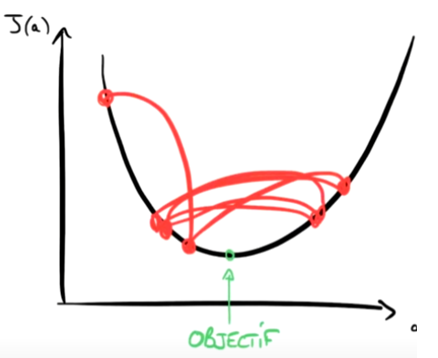
* **If $\eta$ is too small:**
    * The steps are tiny.
    * Convergence is extremely **slow**

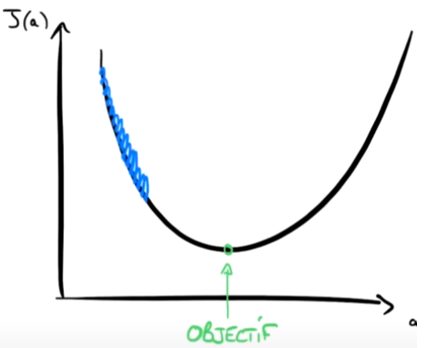
* **If $\eta$ is optimal:**
    * The model converges quickly and stably to a good minimum.

**12. Compare the complexity (depending on the number of layers in the network) of calculating the gradients of the loss with respect to the parameters, using the naive approach and the backprop algorithm.**

Let $L$ be the number of layers and $P$ be the total number of parameters (weights).

**Naive Approach**
To calculate the gradient for **one** parameter $w$, we must perturb it ($w + \epsilon$) and run a full forward pass to see the change in loss.
* We must do this for **every single parameter**.
* **Complexity:** $O(P \times L)$
    *(Because we run a forward pass of cost $L$ for each of the $P$ parameters).*
* **Dependence on Depth:** If the number of parameters $P$ increases linearly with layers $L$, the complexity becomes roughly **quadratic** ($O(L^2)$).

**Backpropagation**
We apply the chain rule recursively from the output to the input. We compute **all** gradients in a single backward pass.
* **Complexity:** $O(L)$
    *(It costs roughly equivalent to just 2 forward passes: 1 forward + 1 backward = $2L$).*
* **Dependence on Depth:** The complexity is **linear** with respect to the number of layers ($O(L)$).


Therefore, backpropagation is exponentially more efficient for deep networks because its cost does not multiply by the number of parameters, unlike the naive approach.

**13. What criteria must the network architecture meet to allow such an optimization procedure?**


To allow optimization via **Backpropagation**  the network architecture must meet the following fundamental criterion:

All components of the network (specifically the **Activation Functions** and the **Loss Function**) must be mainly differentiable.

Indeed, the backpropagation algorithm relies on the **Chain Rule** to calculate gradients.
If a function is not differentiable (like the "Step" function, which has a derivative of 0 everywhere and is undefined at the jump), the gradient cannot be propagated, and the weights cannot be updated.

**14. The function SoftMax and the loss of cross-entropy are often used together and their gradient is very simple. Show that the loss can be simplified by:**

$\ell = - \sum_{i} y_i \tilde{y}_i + \log \left( \sum_{i} e^{\tilde{y}_i} \right)$

**Goal:** Show that $\ell = - \sum_{i} y_i \tilde{y}_i + \log \left( \sum_{i} e^{\tilde{y}_i} \right)$

**1. Note:**
* **Cross-Entropy Loss:** $\ell = - \sum_{i} y_i \log(\hat{y}_i)$
* **Softmax Function:** $\hat{y}_i = \frac{e^{\tilde{y}_i}}{\sum_{k} e^{\tilde{y}_k}}$

**2. Substitution:**
Substitute the Softmax equation into the Loss equation:
$$
\ell = - \sum_{i} y_i \log \left( \frac{e^{\tilde{y}_i}}{\sum_{k} e^{\tilde{y}_k}} \right)
$$

**3. Apply Logarithm Rules:**
Using the quotient rule $\log(\frac{a}{b}) = \log(a) - \log(b)$:
$$
\ell = - \sum_{i} y_i \left( \log(e^{\tilde{y}_i}) - \log\left(\sum_{k} e^{\tilde{y}_k}\right) \right)
$$

**4. Simplify:**
Since $\log(e^x) = x$:
$$
\ell = - \sum_{i} y_i \left( \tilde{y}_i - \log\left(\sum_{k} e^{\tilde{y}_k}\right) \right)
$$

**5. Distribute the Summation:**
$$
\ell = - \sum_{i} y_i \tilde{y}_i + \sum_{i} y_i \log\left(\sum_{k} e^{\tilde{y}_k}\right)
$$

**6.**
Finally the term $\log(\sum_{k} e^{\tilde{y}_k})$ is a constant with respect to the summation index $i$. We can factor it out.
Also, since $y$ is a one-hot encoded vector (or a probability distribution), the sum of all classes $\sum_{i} y_i = 1$.

$$
\ell = - \sum_{i} y_i \tilde{y}_i + \log\left(\sum_{k} e^{\tilde{y}_k}\right) \underbrace{\sum_{i} y_i}_{1}
$$

**Then:**
$$
\ell = - \sum_{i} y_i \tilde{y}_i + \log \left( \sum_{i} e^{\tilde{y}_i} \right)
$$

___
## Section 2 - Implementation
___

We now have all the equations allowing us to make predictions (forward), to evaluate (loss) and to learn (backward and gradient descent) our model.

We are now going to implement this network with PyTorch to gradually familiarize ourself with the framework.

This part is inspired by the PyTorch getting started tutorial available at : https://docs.pytorch.org/tutorials/beginner/pytorch_with_examples.html.

### 2.1 Forward and backward manuals

We will start by coding the neural network by simply using basic mathematical operations and therefore directly transcribing our mathematical equations.

We will use the functions found in the torch :
https://docs.pytorch.org/docs/1.2.0/index.html.

In torch, data is stored in objects of type torch.Tensor , equivalent to numpy.array . The basic PyTorch functions return objects of this type.

**2. Write the function init_params(nx, nh, ny) which initializes the weights of a network from the sizes nx, nh and ny and stores them in a dictionary. All weights will be initialized according to a normal distribution of mean 0 and standard deviation 0.3.**

Hint: use the torch.randn and torch.zeros functions.

In [ ]:
import torch

def init_params(nx, nh, ny):
    """
    Initializes the weights and biases of a network from the
    sizes nx, nh and ny and stores them in a dictionary.

    - Weights (W): Normal dist (mean=0, std=0.3)
    - Biases (b): Zeros
    """
    params = {}

    #### Input Layer nx -> Hidden Layer nh) ####
    #=>h = Wh * x + bh
    #=>Shape of Wh: (nh, nx)
    params["weight_h"] = torch.randn(nh, nx) * 0.3
    params["bias_h"] = torch.zeros(nh, 1)

    #### Hidden Layer nh -> Output Layer ny ####
    # Equation: y = Wy * h + by
    # Shape of Wy: (ny, nh)
    params["weight_y"] = torch.randn(ny, nh) * 0.3
    params["bias_y"] = torch.zeros(ny, 1)

    return params

In [ ]:
# Tests #
params = init_params(nx=2, nh=3, ny=2)

print(f"The final dict : {params}")

The final dict : {'weight_h': tensor([[ 0.3019, -0.1254],
        [-0.2218,  0.1084],
        [-0.4492,  0.1112]]), 'bias_h': tensor([[0.],
        [0.],
        [0.]]), 'weight_y': tensor([[-0.0659,  0.0269, -0.2172],
        [-0.1191, -0.3205, -0.1565]]), 'bias_y': tensor([[0.],
        [0.]])}


**3. Write the function forward (params, X) which calculates the intermediate steps and the output
of the network from an input batch X of size$ n_{batch} \times n_x$ and weights stored in *params* and store them in a dictionary.
We return the dictionary of intermediate steps and the output $\hat{Y}$ of the network.**

Hint: we will use torch.mm for matrix multiplication, and torch.tanh, torch.exp, torch.sum


In [ ]:
def forward(params, X):
    """
    Calculates the forward pass of the network.

    Args:
        params: Dictionary containing weights and biases
        X: Input batch of size (n_batch, nx)

    Returns:
        outputs: Dictionary of intermediate steps
        y_hat: Final output probabilities
    """
    outputs = {}
    outputs["X"] = X

    ######## Hidden Layer h ########
    # 1)Affine transformation
    # Equation: h_tilde = X . Wh^T + bh
    # Note: We use .t() on weights because shapes are (Batch, nx) * (nx, nh) -> (Batch, nh)
    # Note: We use .t() on biases to broadcast (nh, 1) to (1, nh) so it adds to every row
    h_tilde = torch.mm(X, params["weight_h"].t()) + params["bias_h"].t()

    # 2)Activation function : TANH
    h = torch.tanh(h_tilde)

    # Store intermediates
    outputs["h_tilde"] = h_tilde
    outputs["h"] = h

    ######## Output Layer y ########
    # 1)Affine transformation
    # IMPORTANT: The input here is 'h' from hidden layer
    # Equation: y_tilde = h . Wy^T + by
    y_tilde = torch.mm(h, params["weight_y"].t()) + params["bias_y"].t()

    outputs["y_tilde"] = y_tilde

    # 3) Activation function : Softmax
    # Equation: y_hat = exp(y_tilde) / sum(exp(y_tilde))

    # Exponential function
    e_y = torch.exp(y_tilde)
    # Sum of exponentials
    sum_e_y = torch.sum(e_y, dim=1, keepdim=True)

    # Softmax (divide)
    y_hat = e_y / sum_e_y

    outputs["y_hat"] = y_hat

    return outputs, y_hat

In [ ]:
# --- To test it ---

# Dimensions
nx = 2   # Input features
nh = 3   # Hidden neurons
ny = 2   # Output classes
n_batch = 4 # Batch size

#Initialize weights
params = init_params(nx, nh, ny)
X = torch.randn(n_batch, nx)

# Run the forward pass
outputs, y_hat = forward(params, X)

# 4. Visualization
print("###### h ######")
print("Output of h after affine transformation :")
print(outputs["h_tilde"])
print("Output of h after tanh activation :")
print(outputs["h"])
print()
print("###### y ######")
print("Output of y after affine transformation :")
print(outputs["y_tilde"])
print("Output of h after softmax activation :")
print(y_hat)
print()


###### h ######
Output of h after affine transformation :
tensor([[ 0.1909, -0.3281, -0.1053],
        [-0.2849, -0.9250,  0.6389],
        [-0.1193, -0.2064,  0.2059],
        [-0.2503,  2.3892, -0.5291]])
Output of h after tanh activation :
tensor([[ 0.1886, -0.3168, -0.1049],
        [-0.2774, -0.7282,  0.5642],
        [-0.1187, -0.2035,  0.2031],
        [-0.2452,  0.9833, -0.4847]])

###### y ######
Output of y after affine transformation :
tensor([[-0.0743, -0.0204],
        [ 0.4150, -0.1748],
        [ 0.1496, -0.0565],
        [-0.1537,  0.0353]])
Output of h after softmax activation :
tensor([[0.4865, 0.5135],
        [0.6433, 0.3567],
        [0.5514, 0.4486],
        [0.4529, 0.5471]])



**4. Write the function loss_accuracy (Yhat, Y) which computes the cost function and the precision (rate of good predictions) from an output matrix $\hat{Y}$ (output of forward ) with respect to a ground truth matrix $Y$ of the same size, and returns the *loss* $L$ and the precision *acc*.**

Note: We will use the _, indsY = torch.max (Y, 1) function which returns the index of the
predicted class (or to be predicted) for each example.

Hints: torch.mean, torch.max, torch.log, torch.sum

#### Use of cross-entropy loss
Because our output comes from softmax, we have probabilities, therfore, we use cross-entropy loss function well suited for probabilities and more efficient than MSE with Softmax.

#### Cross-Entropy Loss Implementation

**1. Loss per example (Vector):**
First, we calculate the loss for each individual example $i$ in the batch. Since $Y$ is one-hot encoded, this selects the log-probability of the correct class:
$$
\ell^{(i)} = - \sum_{k} y_k^{(i)} \log(\hat{y}_k^{(i)})
$$


**2. Global Cost Function (Scalar):**
To perform **Gradient Descent**, we need to minimize a **single scalar value** that summarizes the performance of the entire batch. We obtain this by averaging the individual losses over the batch size $N$:
$$
L = \frac{1}{N} \sum_{i=1}^{N} \ell^{(i)}
$$

In [ ]:
def loss_accuracy(Yhat, Y):
    """
    Computes the Cross-Entropy cost function and the precision (accuracy).

    Args:
        Yhat: Output of forward pass (predicted probabilities) - Shape (N, C)
        Y: Ground truth (One-hot encoded) - Shape (N, C)

    Returns:
        L: The average cross-entropy loss
        acc: The accuracy (0.0 to 1.0)
    """

    ########## Cross-Entropy Loss ##########
    # Loss per example: l = - sum( Y_i * log(Yhat_i) )
    # Global Cost Function : L = (1/N)sum( l(Y_i * Yhat_i) )
    #   => In our case : L = - (1/N)sum( Y_i * log(Yhat_i) )
    # we need it in gradient descent so as to to minimize a single scalar value *
    # that summarizes the performance of the whole batch(less computation)

    # log(y_hat_i)
    log_Yhat = torch.log(Yhat)

    # y_i * log(y_hat_i)
    selected_logs = Y * log_Yhat

    # Loss per example: l = - sum( Y_i * log(Yhat_i) )
    loss_per_example = -torch.sum(selected_logs, dim=1)

    # Loss as a global score : L = - (1/N)sum( Y_i * log(Yhat_i) )
    L = torch.mean(loss_per_example)

    ########## Accuracy ##########
    # Find the class index with the highest probability for prediction and truth
    _, indsYhat = torch.max(Yhat, 1) # prediction
    _, indsY = torch.max(Y, 1) # truth

    # Compare indices (creates a tensor of True/False)
    matches = (indsYhat == indsY)

    # Convert Boolean to Float (True=1.0, False=0.0) and calculate mean
    acc = torch.mean(matches.float())

    return L, acc

In [ ]:
##### Test Cell #####

# Y_hat and Y of size 3x3
Yhat = torch.tensor([[0.1, 0.8, 0.1],   # Prediction: Class 1 (Correct)
                     [0.9, 0.05, 0.05], # Prediction: Class 0 (Correct)
                     [0.3, 0.4, 0.3]])  # Prediction: Class 1 (Wrong, Truth is 2)

Y = torch.tensor([[0, 1, 0],   # Truth: Class 1
                  [1, 0, 0],   # Truth: Class 0
                  [0, 0, 1]])  # Truth: Class 2

# 2. Run function
loss, accuracy = loss_accuracy(Yhat, Y)

print(f"Loss: {loss:.4f}")
print(f"Accuracy: {accuracy:.2f} ") #Expected: 0.67 because 2/3 are correct

Loss: 0.5108
Accuracy: 0.67 


**5. Write the function backward (params, outputs, Y) which calculates the gradients of the loss
with respect to the parameters and stores them in a dictionary.**

In [ ]:
def backward(params, outputs, Y):
    """
    Calculates the gradients of the loss with respect to the parameters.

    Args:
        params: Dictionary of weights/biases
        outputs: Dictionary of intermediate values (must contain 'X', 'h', 'y_hat')
        Y: Ground truth (One-hot encoded)

    Returns:
        grads: Dictionary containing gradients ('grad_Wh', 'grad_bh', 'grad_Wy', 'grad_by')
    """
    grads = {}

    ########## From outputs ##########
    X = outputs["X"]
    y_hat = outputs["y_hat"]
    h = outputs["h"]
    Wy = params["weight_y"]

    # Get batch size N for averaging the gradient
    N = X.shape[0]

    ########## Gradient of Output Layer y ##########
    # Derivative of Cross-Entropy + Softmax is (y_hat - Y)
    # We divide by N because the Loss is the *mean* over the batch
    delta_y_tilde = (y_hat - Y) / N

    # Gradient for Wy: (ny, nh) = (ny, N) * (N, nh)
    grads["grad_Wy"] = torch.mm(delta_y_tilde.t(), h)

    # Gradient for by: Sum over batch dimension
    # Shape becomes (ny, 1) to match init_params
    grads["grad_by"] = torch.sum(delta_y_tilde, dim=0, keepdim=True).t()

    ########## Gradient of Hidden Layer h ##########
    # Backpropagate error to hidden layer: (N, nh) = (N, ny) * (ny, nh)
    delta_h = torch.mm(delta_y_tilde, Wy)

    # Derivative of tanh(x) is (1 - tanh(x)^2)
    # So: delta_h_tilde = delta_h * (1 - h^2)
    delta_h_tilde = delta_h * (1 - torch.pow(h, 2))

    # Gradient for Wh: (nh, nx) = (nh, N) * (N, nx)
    grads["grad_Wh"] = torch.mm(delta_h_tilde.t(), X)

    # Gradient for bh: Sum over batch dimension
    grads["grad_bh"] = torch.sum(delta_h_tilde, dim=0, keepdim=True).t()

    return grads

In [ ]:
##### Test Cell #####
nx, nh, ny, N = 2, 3, 2, 4
params = init_params(nx, nh, ny)
X = torch.randn(N, nx)
Y = torch.tensor([[1, 0], [0, 1], [1, 0], [0, 1]]).float()
# Backward
grads = backward(params, outputs, Y)

# Print
print("Gradients ")
print("grad_Wh:", grads["grad_Wh"])
print("grad_bh:", grads["grad_bh"] )
print("grad_Wy:", grads["grad_Wy"] )
print("grad_by:", grads["grad_by"] )

Gradients 
grad_Wh: tensor([[-0.0995,  0.0111],
        [ 0.0145, -0.0504],
        [-0.0882, -0.0011]])
grad_bh: tensor([[-0.0082],
        [-0.0800],
        [ 0.0150]])
grad_Wy: tensor([[-0.0833,  0.0577,  0.0265],
        [ 0.0833, -0.0577, -0.0265]])
grad_by: tensor([[ 0.0335],
        [-0.0335]])


**6. Write the function sgd (params, grads, eta) which applies a stochastic gradient descent by
mini-batch and updates the network parameters from their gradients and the learning step.**

#### SGD Update Rule

For each parameter $\theta$ (weights $W$ and biases $b$), we update its value by moving in the opposite direction of the gradient:

$$
\theta \leftarrow \theta - \eta \frac{\partial L}{\partial \theta}
$$

Where:
* $\eta$ (eta) is the **learning rate**.
* $\frac{\partial L}{\partial \theta}$ is the gradient computed during the backward pass.

In [ ]:
def sgd(params, grads, eta):
    """
    Applies Stochastic Gradient Descent to update parameters.

    Args:
        params: Dictionary containing the current weights and biases
        grads: Dictionary containing the gradients (from backward pass)
        eta: Learning rate (step size)

    Returns:
        params: Updated dictionary of parameters
    """

    # Update Hidden Layer
    # W = W - eta * grad
    params["weight_h"] = params["weight_h"] - eta * grads["grad_Wh"]
    params["bias_h"]   = params["bias_h"]   - eta * grads["grad_bh"]

    # Update Output Layer
    params["weight_y"] = params["weight_y"] - eta * grads["grad_Wy"]
    params["bias_y"]   = params["bias_y"]   - eta * grads["grad_by"]

    return params

In [ ]:
###### Test Cell ######
params = {
    "weight_h": torch.tensor([[1.0, 1.0]]),
    "bias_h":   torch.tensor([[0.0]]),
    "weight_y": torch.tensor([[1.0, 1.0]]),
    "bias_y":   torch.tensor([[0.0]])
}
grads = {
    "grad_Wh": torch.tensor([[0.1, 0.1]]),
    "grad_bh": torch.tensor([[0.1]]),
    "grad_Wy": torch.tensor([[0.1, 0.1]]),
    "grad_by": torch.tensor([[0.1]])
}

eta = 0.5 #step

# Print Before
print("Weight H (Before):", params["weight_h"])
print("Weight Y (Before):", params["weight_y"])

# Apply SGD
params = sgd(params, grads, eta)

# Print After
# Expected: 1.0 - (0.5 * 0.1) = 0.95
print("Weight H (After): ", params["weight_h"])
print("Weight Y (After): ", params["weight_y"])

Weight H (Before): tensor([[1., 1.]])
Weight Y (Before): tensor([[1., 1.]])
Weight H (After):  tensor([[0.9500, 0.9500]])
Weight Y (After):  tensor([[0.9500, 0.9500]])


**7. Write the global learning algorithm using these functions.**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

def global_learning_alg(nx,nh,ny,eta,n_epochs,batch_size):

  ######## Load / Prepare Data ########
  # Generate a dataset that requires a non-linear decision boundary
  X_np, Y_np = make_circles(n_samples=500, noise=0.05, factor=0.5, random_state=42)

  # Convert labels to One-Hot Encoding for our Cross-Entropy logic
  # Class 0 -> [1, 0], Class 1 -> [0, 1]
  Y_onehot = np.zeros((Y_np.size, 2))
  Y_onehot[np.arange(Y_np.size), Y_np] = 1

  # Split Train 70% / Test 30%
  X_train_np, X_test_np, Y_train_np, Y_test_np = train_test_split(X_np, Y_onehot, test_size=0.3, random_state=42)

  # Convert to PyTorch Tensors
  X_train = torch.tensor(X_train_np).float()
  Y_train = torch.tensor(Y_train_np).float()
  X_test  = torch.tensor(X_test_np).float()
  Y_test  = torch.tensor(Y_test_np).float()

  N = X_train.shape[0]
  # Init weights
  params = init_params(nx, nh, ny)

  # To store loss/accuracy history for plotting
  history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

  ######## Global Training Loop ########
  print(f"Starting training for {n_epochs} epochs...")

  for i in range(n_epochs):

      # Shuffle data at the start of each epoch (Stochastic Gradient Descent)
      indices = torch.randperm(N)
      X_train_shuffled = X_train[indices]
      Y_train_shuffled = Y_train[indices]

      # Iterate on batches
      for j in range(0, N, batch_size):
          # (Xbatch, Ybatch) <- subsets of training samples
          # Handle the last batch even if it's smaller than batch_size
          end_idx = min(j + batch_size, N)
          Xbatch = X_train_shuffled[j:end_idx]
          Ybatch = Y_train_shuffled[j:end_idx]

          # Batch Forward Pass
          outputs, Y_hat_batch = forward(params, Xbatch)

          # Batch Backward Pass (Calculate Gradients)
          # (forward already stored 'X' in outputs)
          grads = backward(params, outputs, Ybatch)

          # 3. Gradient Descent Step (Update Parameters)
          params = sgd(params, grads, eta)

      ######## Compute full stats on Train and Test sets ########
      _, Y_hat_train_full = forward(params, X_train)
      _, Y_hat_test_full  = forward(params, X_test)

      train_loss, train_acc = loss_accuracy(Y_hat_train_full, Y_train)
      test_loss, test_acc   = loss_accuracy(Y_hat_test_full, Y_test)

      # Store history
      history['train_loss'].append(train_loss)
      history['train_acc'].append(train_acc)
      history['test_loss'].append(test_loss)
      history['test_acc'].append(test_acc)

      # Print every 20 epochs
      if (i+1) % 20 == 0:
          print(f"Epoch {i+1}/{n_epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.2f} | Test Loss: {test_loss:.4f} Acc: {test_acc:.2f}")


  ######## Showing Loss Dynamics ########
  plt.figure(figsize=(12, 5))

  # Plot Loss
  plt.subplot(1, 2, 1)
  plt.plot(history['train_loss'], label='Train Loss')
  plt.plot(history['test_loss'], label='Test Loss')
  plt.title('Loss Dynamics')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()
  plt.grid(True)

  # Plot Accuracy
  plt.subplot(1, 2, 2)
  plt.plot(history['train_acc'], label='Train Acc')
  plt.plot(history['test_acc'], label='Test Acc')
  plt.title('Accuracy Dynamics')
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.legend()
  plt.grid(True)

  plt.show()

Starting training for 200 epochs...
Epoch 20/200 | Train Loss: 0.6208 Acc: 0.68 | Test Loss: 0.6288 Acc: 0.64
Epoch 40/200 | Train Loss: 0.3972 Acc: 1.00 | Test Loss: 0.3990 Acc: 1.00
Epoch 60/200 | Train Loss: 0.1785 Acc: 1.00 | Test Loss: 0.1773 Acc: 1.00
Epoch 80/200 | Train Loss: 0.0954 Acc: 1.00 | Test Loss: 0.0934 Acc: 1.00
Epoch 100/200 | Train Loss: 0.0613 Acc: 1.00 | Test Loss: 0.0592 Acc: 1.00
Epoch 120/200 | Train Loss: 0.0443 Acc: 1.00 | Test Loss: 0.0422 Acc: 1.00
Epoch 140/200 | Train Loss: 0.0343 Acc: 1.00 | Test Loss: 0.0324 Acc: 1.00
Epoch 160/200 | Train Loss: 0.0278 Acc: 1.00 | Test Loss: 0.0262 Acc: 1.00
Epoch 180/200 | Train Loss: 0.0234 Acc: 1.00 | Test Loss: 0.0218 Acc: 1.00
Epoch 200/200 | Train Loss: 0.0201 Acc: 1.00 | Test Loss: 0.0186 Acc: 1.00


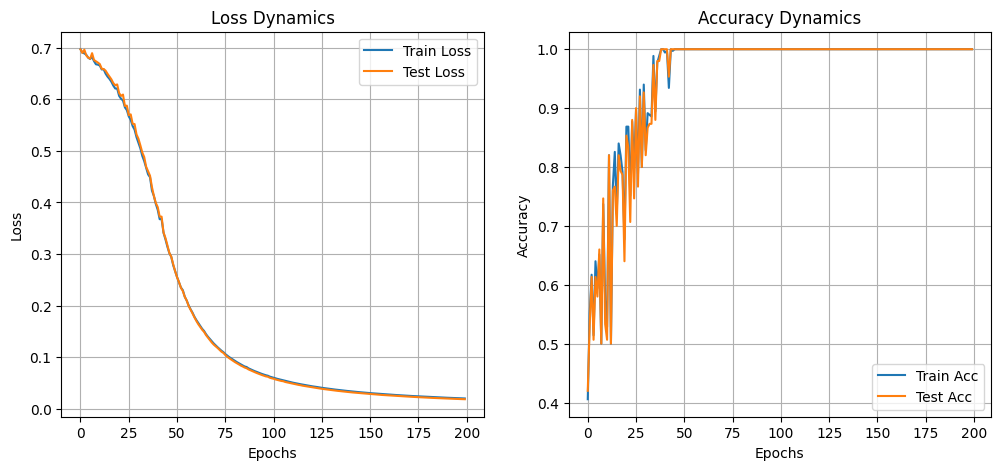

In [ ]:
######## Initialize Network & Hyperparameters ########
nx = 2    # Input features
nh = 100  # Hidden neurons : we will try different ones
ny = 2    # Output classes
eta = 0.05 # Learning rate
n_epochs = 200
batch_size = 16
global_learning_alg(nx,nh,ny,eta,n_epochs,batch_size)



___
Lets now try if for different values of parameters.
First we only modifying the size of hidden layer :

Starting training for 200 epochs...
Epoch 20/200 | Train Loss: 0.6934 Acc: 0.50 | Test Loss: 0.6933 Acc: 0.50
Epoch 40/200 | Train Loss: 0.6932 Acc: 0.50 | Test Loss: 0.6932 Acc: 0.49
Epoch 60/200 | Train Loss: 0.6932 Acc: 0.51 | Test Loss: 0.6932 Acc: 0.49
Epoch 80/200 | Train Loss: 0.6932 Acc: 0.50 | Test Loss: 0.6933 Acc: 0.50
Epoch 100/200 | Train Loss: 0.6931 Acc: 0.43 | Test Loss: 0.6932 Acc: 0.43
Epoch 120/200 | Train Loss: 0.6931 Acc: 0.58 | Test Loss: 0.6933 Acc: 0.54
Epoch 140/200 | Train Loss: 0.6931 Acc: 0.39 | Test Loss: 0.6933 Acc: 0.41
Epoch 160/200 | Train Loss: 0.6931 Acc: 0.47 | Test Loss: 0.6933 Acc: 0.47
Epoch 180/200 | Train Loss: 0.6931 Acc: 0.47 | Test Loss: 0.6933 Acc: 0.46
Epoch 200/200 | Train Loss: 0.6931 Acc: 0.46 | Test Loss: 0.6934 Acc: 0.43


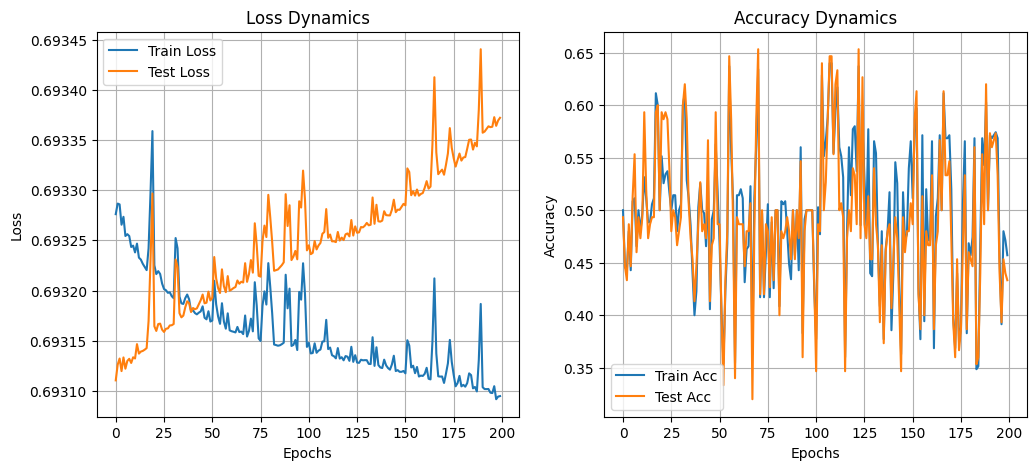

Starting training for 200 epochs...
Epoch 20/200 | Train Loss: 0.6921 Acc: 0.54 | Test Loss: 0.6930 Acc: 0.49
Epoch 40/200 | Train Loss: 0.6896 Acc: 0.64 | Test Loss: 0.6910 Acc: 0.63
Epoch 60/200 | Train Loss: 0.6762 Acc: 0.71 | Test Loss: 0.6786 Acc: 0.69
Epoch 80/200 | Train Loss: 0.6095 Acc: 0.80 | Test Loss: 0.6182 Acc: 0.76
Epoch 100/200 | Train Loss: 0.5310 Acc: 0.79 | Test Loss: 0.5516 Acc: 0.76
Epoch 120/200 | Train Loss: 0.5006 Acc: 0.79 | Test Loss: 0.5305 Acc: 0.76
Epoch 140/200 | Train Loss: 0.4867 Acc: 0.78 | Test Loss: 0.5210 Acc: 0.74
Epoch 160/200 | Train Loss: 0.4773 Acc: 0.79 | Test Loss: 0.5145 Acc: 0.75
Epoch 180/200 | Train Loss: 0.4711 Acc: 0.80 | Test Loss: 0.5092 Acc: 0.74
Epoch 200/200 | Train Loss: 0.4667 Acc: 0.80 | Test Loss: 0.5072 Acc: 0.76


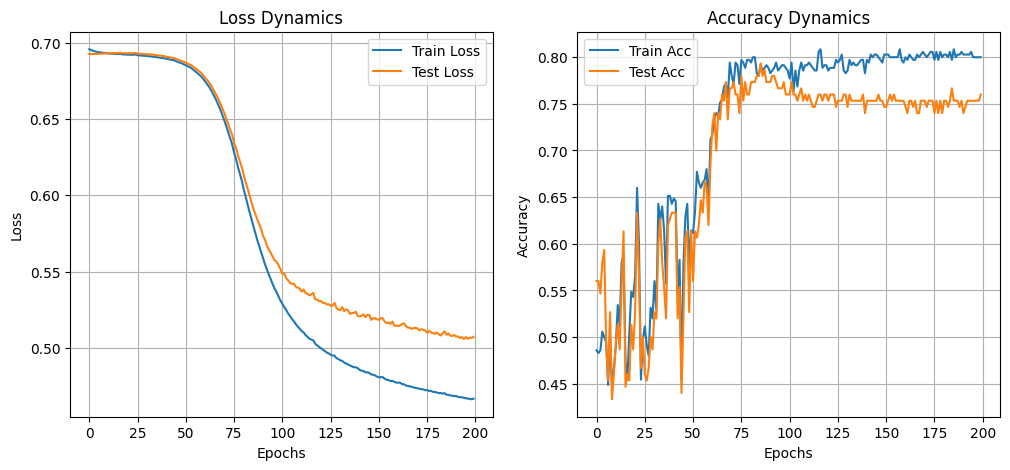

Starting training for 200 epochs...
Epoch 20/200 | Train Loss: 0.6931 Acc: 0.49 | Test Loss: 0.6953 Acc: 0.45
Epoch 40/200 | Train Loss: 0.6929 Acc: 0.55 | Test Loss: 0.6947 Acc: 0.52
Epoch 60/200 | Train Loss: 0.6927 Acc: 0.50 | Test Loss: 0.6943 Acc: 0.48
Epoch 80/200 | Train Loss: 0.6924 Acc: 0.49 | Test Loss: 0.6942 Acc: 0.47
Epoch 100/200 | Train Loss: 0.6918 Acc: 0.51 | Test Loss: 0.6938 Acc: 0.49
Epoch 120/200 | Train Loss: 0.6902 Acc: 0.51 | Test Loss: 0.6927 Acc: 0.47
Epoch 140/200 | Train Loss: 0.6843 Acc: 0.56 | Test Loss: 0.6878 Acc: 0.51
Epoch 160/200 | Train Loss: 0.6580 Acc: 0.66 | Test Loss: 0.6619 Acc: 0.68
Epoch 180/200 | Train Loss: 0.5699 Acc: 0.83 | Test Loss: 0.5696 Acc: 0.83
Epoch 200/200 | Train Loss: 0.4076 Acc: 0.96 | Test Loss: 0.4043 Acc: 0.96


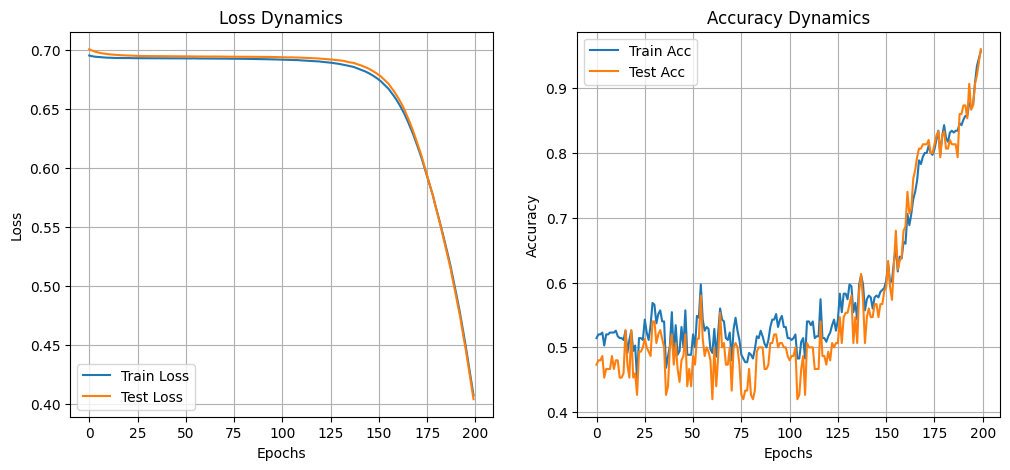

Starting training for 200 epochs...
Epoch 20/200 | Train Loss: 0.6588 Acc: 0.65 | Test Loss: 0.6592 Acc: 0.64
Epoch 40/200 | Train Loss: 0.5586 Acc: 0.81 | Test Loss: 0.5606 Acc: 0.79
Epoch 60/200 | Train Loss: 0.4064 Acc: 0.90 | Test Loss: 0.4116 Acc: 0.90
Epoch 80/200 | Train Loss: 0.2167 Acc: 1.00 | Test Loss: 0.2184 Acc: 1.00
Epoch 100/200 | Train Loss: 0.1340 Acc: 1.00 | Test Loss: 0.1359 Acc: 1.00
Epoch 120/200 | Train Loss: 0.0951 Acc: 1.00 | Test Loss: 0.0980 Acc: 1.00
Epoch 140/200 | Train Loss: 0.0736 Acc: 1.00 | Test Loss: 0.0770 Acc: 1.00
Epoch 160/200 | Train Loss: 0.0603 Acc: 1.00 | Test Loss: 0.0642 Acc: 1.00
Epoch 180/200 | Train Loss: 0.0511 Acc: 1.00 | Test Loss: 0.0551 Acc: 1.00
Epoch 200/200 | Train Loss: 0.0445 Acc: 1.00 | Test Loss: 0.0485 Acc: 1.00


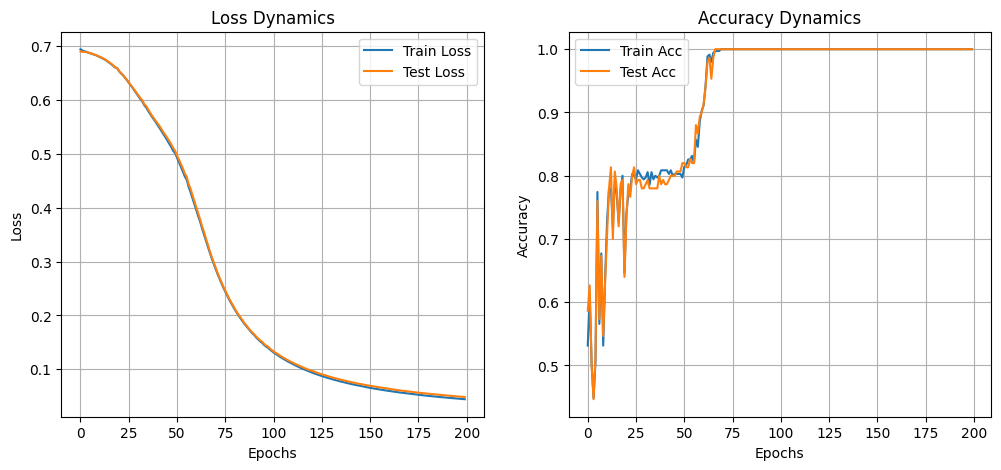

Starting training for 200 epochs...
Epoch 20/200 | Train Loss: 0.6308 Acc: 0.83 | Test Loss: 0.6332 Acc: 0.87
Epoch 40/200 | Train Loss: 0.4584 Acc: 0.99 | Test Loss: 0.4558 Acc: 1.00
Epoch 60/200 | Train Loss: 0.2115 Acc: 1.00 | Test Loss: 0.2122 Acc: 1.00
Epoch 80/200 | Train Loss: 0.1039 Acc: 1.00 | Test Loss: 0.1030 Acc: 1.00
Epoch 100/200 | Train Loss: 0.0628 Acc: 1.00 | Test Loss: 0.0625 Acc: 1.00
Epoch 120/200 | Train Loss: 0.0436 Acc: 1.00 | Test Loss: 0.0433 Acc: 1.00
Epoch 140/200 | Train Loss: 0.0330 Acc: 1.00 | Test Loss: 0.0328 Acc: 1.00
Epoch 160/200 | Train Loss: 0.0262 Acc: 1.00 | Test Loss: 0.0260 Acc: 1.00
Epoch 180/200 | Train Loss: 0.0216 Acc: 1.00 | Test Loss: 0.0215 Acc: 1.00
Epoch 200/200 | Train Loss: 0.0184 Acc: 1.00 | Test Loss: 0.0183 Acc: 1.00


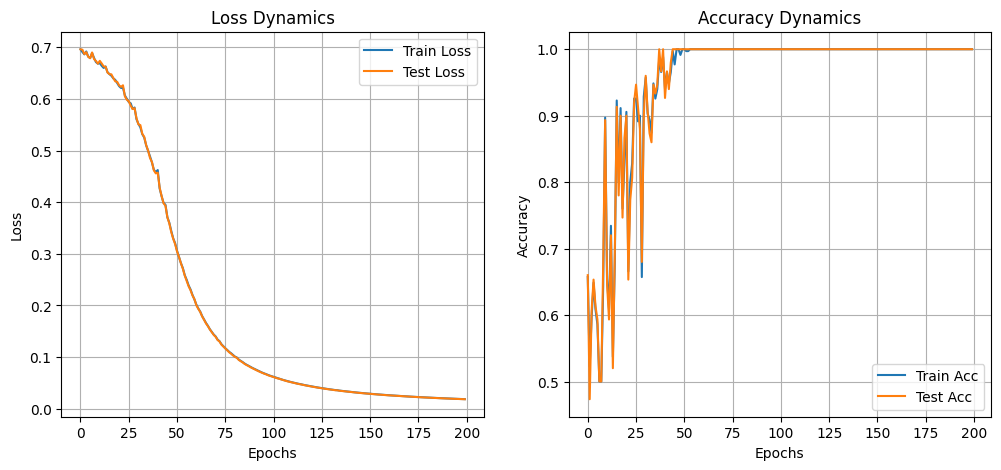

In [ ]:
######## Fixed Parameters ########
nx = 2    # Input features
ny = 2    # Output classes
eta = 0.05 # Learning rate
n_epochs = 200
batch_size = 16

######## Unfixed Parameter ########
nh = [1,3,6,12,100]  # Hidden neurons

for i_nh in nh :
  global_learning_alg(nx,i_nh,ny,eta,n_epochs,batch_size)


* $n_h=1, n_h=3$ :
In the first two graphs, the loss decreases very slowly, and the accuracy fluctuates around 0.5 The model is too simple. With only 1 or 3 neurons, the network lacks the geometric "capacity" to separate non-linear data (like concentric circles). It effectively behaves like a linear classifier, resulting in underfitting.

* $n_h=6, n_h=12$ :
As soon as we increase to $n_h=6$, performance explodes. The loss drops rapidly to near zero, and accuracy hits 100% quickly and stays there. $n_h=12$ shows a similar, very stable perfect result.The network now has enough neurons to approximate the non-linear boundary required to distinguish the two classes.

* $n_h=100$ :
The model still achieves 100% accuracy, but the early epochs show more volatility (noise) compared to the smoother curves of $n_h=12$.
While the model solves the task, it is over-parameterized.

Therefore, there is a threshold around $n_h=6$ in this case below which the model fails completely. Once we pass that threshold, the model solves the task, but adding significantly more neurons ($n_h=100$) yields just adds computational cost.

___
Then let's try modifying the batch size :

############################################################
########## For batch_size = 1 ##########
Starting training for 200 epochs...
Epoch 20/200 | Train Loss: 0.0629 Acc: 0.99 | Test Loss: 0.0580 Acc: 1.00
Epoch 40/200 | Train Loss: 0.0291 Acc: 1.00 | Test Loss: 0.0246 Acc: 1.00
Epoch 60/200 | Train Loss: 0.0229 Acc: 1.00 | Test Loss: 0.0130 Acc: 1.00
Epoch 80/200 | Train Loss: 0.0166 Acc: 1.00 | Test Loss: 0.0163 Acc: 1.00
Epoch 100/200 | Train Loss: 0.0109 Acc: 1.00 | Test Loss: 0.0073 Acc: 1.00
Epoch 120/200 | Train Loss: 0.0098 Acc: 1.00 | Test Loss: 0.0066 Acc: 1.00
Epoch 140/200 | Train Loss: 0.0089 Acc: 1.00 | Test Loss: 0.0047 Acc: 1.00
Epoch 160/200 | Train Loss: 0.0080 Acc: 1.00 | Test Loss: 0.0056 Acc: 1.00
Epoch 180/200 | Train Loss: 0.0063 Acc: 1.00 | Test Loss: 0.0038 Acc: 1.00
Epoch 200/200 | Train Loss: 0.0056 Acc: 1.00 | Test Loss: 0.0038 Acc: 1.00


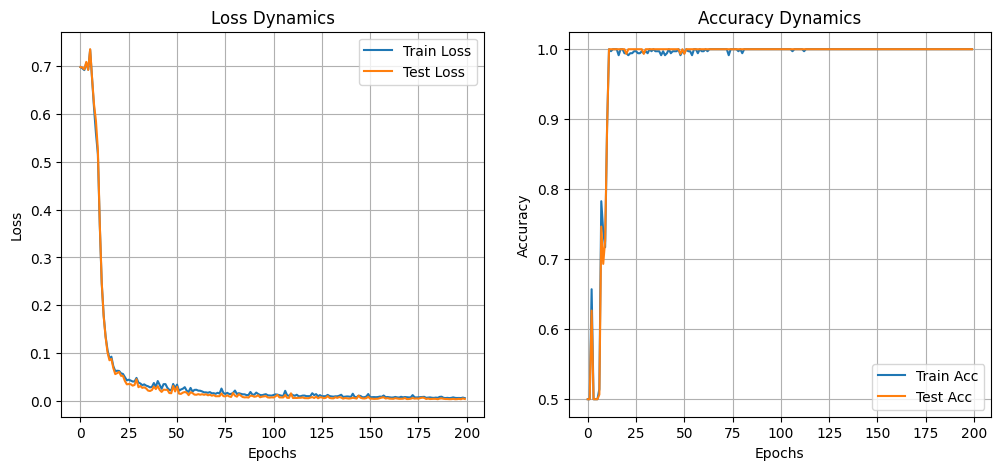

############################################################
############################################################
########## For batch_size = 16 ##########
Starting training for 200 epochs...
Epoch 20/200 | Train Loss: 0.6930 Acc: 0.56 | Test Loss: 0.6931 Acc: 0.53
Epoch 40/200 | Train Loss: 0.6926 Acc: 0.52 | Test Loss: 0.6936 Acc: 0.45
Epoch 60/200 | Train Loss: 0.6920 Acc: 0.51 | Test Loss: 0.6931 Acc: 0.46
Epoch 80/200 | Train Loss: 0.6901 Acc: 0.56 | Test Loss: 0.6911 Acc: 0.50
Epoch 100/200 | Train Loss: 0.6817 Acc: 0.59 | Test Loss: 0.6818 Acc: 0.57
Epoch 120/200 | Train Loss: 0.6434 Acc: 0.74 | Test Loss: 0.6388 Acc: 0.78
Epoch 140/200 | Train Loss: 0.5707 Acc: 0.75 | Test Loss: 0.5564 Acc: 0.78
Epoch 160/200 | Train Loss: 0.5298 Acc: 0.77 | Test Loss: 0.5084 Acc: 0.79
Epoch 180/200 | Train Loss: 0.5117 Acc: 0.77 | Test Loss: 0.4913 Acc: 0.79
Epoch 200/200 | Train Loss: 0.5000 Acc: 0.77 | Test Loss: 0.4806 Acc: 0.81


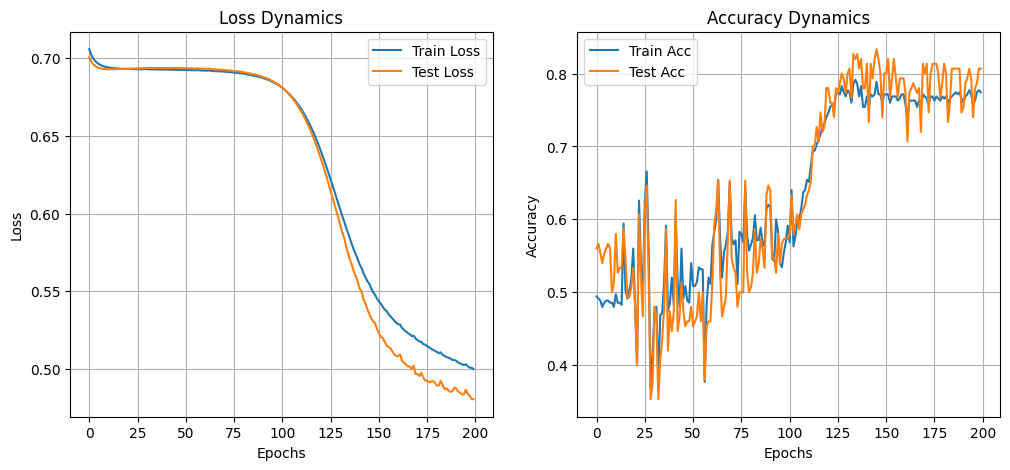

############################################################
############################################################
########## For batch_size = 64 ##########
Starting training for 200 epochs...
Epoch 20/200 | Train Loss: 0.6920 Acc: 0.54 | Test Loss: 0.6929 Acc: 0.53
Epoch 40/200 | Train Loss: 0.6902 Acc: 0.65 | Test Loss: 0.6919 Acc: 0.66
Epoch 60/200 | Train Loss: 0.6880 Acc: 0.64 | Test Loss: 0.6899 Acc: 0.58
Epoch 80/200 | Train Loss: 0.6845 Acc: 0.61 | Test Loss: 0.6872 Acc: 0.59
Epoch 100/200 | Train Loss: 0.6792 Acc: 0.68 | Test Loss: 0.6826 Acc: 0.66
Epoch 120/200 | Train Loss: 0.6704 Acc: 0.75 | Test Loss: 0.6746 Acc: 0.75
Epoch 140/200 | Train Loss: 0.6578 Acc: 0.75 | Test Loss: 0.6625 Acc: 0.75
Epoch 160/200 | Train Loss: 0.6406 Acc: 0.76 | Test Loss: 0.6458 Acc: 0.80
Epoch 180/200 | Train Loss: 0.6190 Acc: 0.78 | Test Loss: 0.6238 Acc: 0.81
Epoch 200/200 | Train Loss: 0.5953 Acc: 0.78 | Test Loss: 0.5997 Acc: 0.83


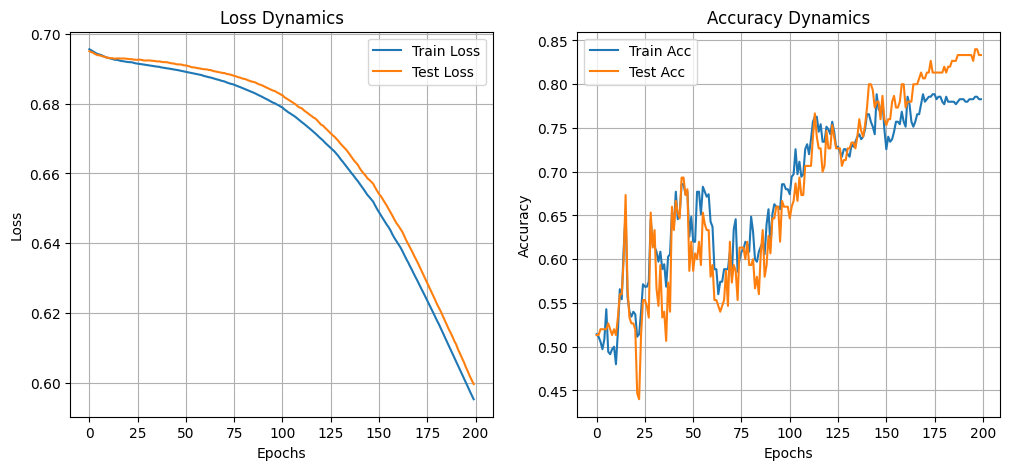

############################################################
############################################################
########## For batch_size = 500 ##########
Starting training for 200 epochs...
Epoch 20/200 | Train Loss: 0.6948 Acc: 0.49 | Test Loss: 0.6936 Acc: 0.53
Epoch 40/200 | Train Loss: 0.6944 Acc: 0.48 | Test Loss: 0.6933 Acc: 0.54
Epoch 60/200 | Train Loss: 0.6942 Acc: 0.49 | Test Loss: 0.6931 Acc: 0.53
Epoch 80/200 | Train Loss: 0.6939 Acc: 0.49 | Test Loss: 0.6930 Acc: 0.54
Epoch 100/200 | Train Loss: 0.6937 Acc: 0.48 | Test Loss: 0.6929 Acc: 0.55
Epoch 120/200 | Train Loss: 0.6936 Acc: 0.48 | Test Loss: 0.6928 Acc: 0.56
Epoch 140/200 | Train Loss: 0.6934 Acc: 0.49 | Test Loss: 0.6928 Acc: 0.56
Epoch 160/200 | Train Loss: 0.6933 Acc: 0.49 | Test Loss: 0.6928 Acc: 0.57
Epoch 180/200 | Train Loss: 0.6932 Acc: 0.49 | Test Loss: 0.6928 Acc: 0.57
Epoch 200/200 | Train Loss: 0.6932 Acc: 0.50 | Test Loss: 0.6928 Acc: 0.58


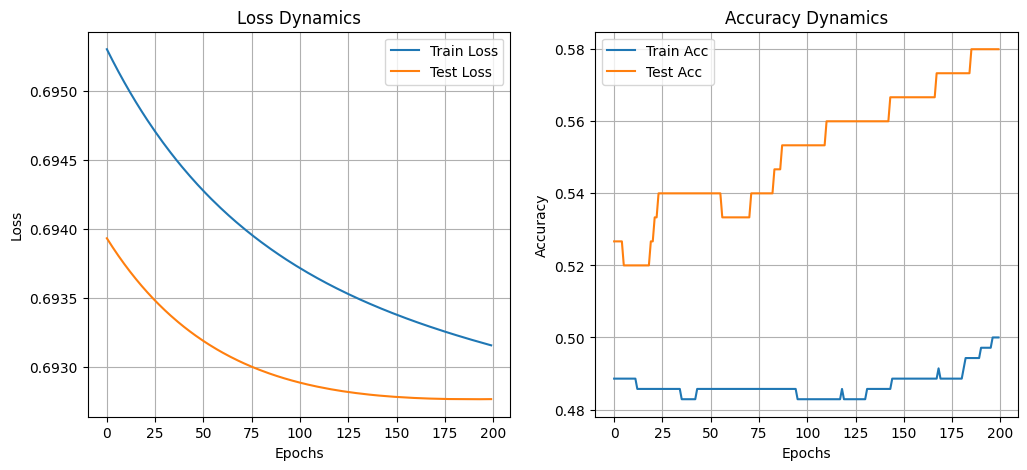

############################################################


In [ ]:
######## Fixed Parameters ########
nx = 2    # Input features
nh = 6  # Hidden neurons
ny = 2    # Output classes
eta = 0.05 # Learning rate
n_epochs = 200

######## Unfixed Parameter ########
batch_size = [1, 16, 64, 500]

for i_batch_size in batch_size :
  print("############################################################")
  print(f"########## For batch_size = {i_batch_size} ##########")
  global_learning_alg(nx,nh,ny,eta,n_epochs,i_batch_size )
  print("############################################################")


* Batch Size = 1 :    
The accuracy remains stuck at 0.50 and the loss oscillates without decreasing significantly.
It looks like there is too much noise: Calculating the gradient on a single example creates a very "noisy" direction. The model keeps overshooting the minimum and cannot settle.

* Batch Size = 16 :  
The loss drops rapidly, and the accuracy hits 100% (1.00) around epoch 120.Averaging over 16 examples reduces the noise enough to get a reliable gradient direction, while still allowing for many updates per epoch (approx. $350 / 16 \approx 22$ updates per epoch).

* Batch Size = 64 :    
The model learns correctly (accuracy reaches ~0.82), but much slower than with Batch Size 16. With a larger batch, we do fewer updates per epoch ($350 / 64 \approx 5$ updates). Even though the gradient is more accurate, the model simply takes fewer steps towards the solution in the same amount of time.

* Batch Size = 500 :     
The loss curve is extremely smooth (almost a straight line), but the learning is extremely slow. Accuracy only crawls up to 0.60.
  * 1 Epoch = 1 Update: Since the batch size
($500$) is larger than the training set ($350$), the model only updates its weights once per epoch.
  * After 200 epochs, the model has only taken 200 steps. Compare this to Batch Size 16, which took over 4000 steps in the same time. The model simply hasn't had enough time to walk down the hill.


___
Then let's try modifying the learning rate :

############################################################
########## For learning_rate = 0.001 ##########
Starting training for 200 epochs...
Epoch 20/200 | Train Loss: 0.6934 Acc: 0.52 | Test Loss: 0.6961 Acc: 0.46
Epoch 40/200 | Train Loss: 0.6933 Acc: 0.53 | Test Loss: 0.6959 Acc: 0.46
Epoch 60/200 | Train Loss: 0.6932 Acc: 0.53 | Test Loss: 0.6957 Acc: 0.47
Epoch 80/200 | Train Loss: 0.6931 Acc: 0.53 | Test Loss: 0.6955 Acc: 0.46
Epoch 100/200 | Train Loss: 0.6930 Acc: 0.53 | Test Loss: 0.6953 Acc: 0.46
Epoch 120/200 | Train Loss: 0.6929 Acc: 0.53 | Test Loss: 0.6952 Acc: 0.47
Epoch 140/200 | Train Loss: 0.6929 Acc: 0.53 | Test Loss: 0.6950 Acc: 0.47
Epoch 160/200 | Train Loss: 0.6928 Acc: 0.53 | Test Loss: 0.6949 Acc: 0.46
Epoch 180/200 | Train Loss: 0.6927 Acc: 0.53 | Test Loss: 0.6948 Acc: 0.47
Epoch 200/200 | Train Loss: 0.6927 Acc: 0.53 | Test Loss: 0.6947 Acc: 0.47


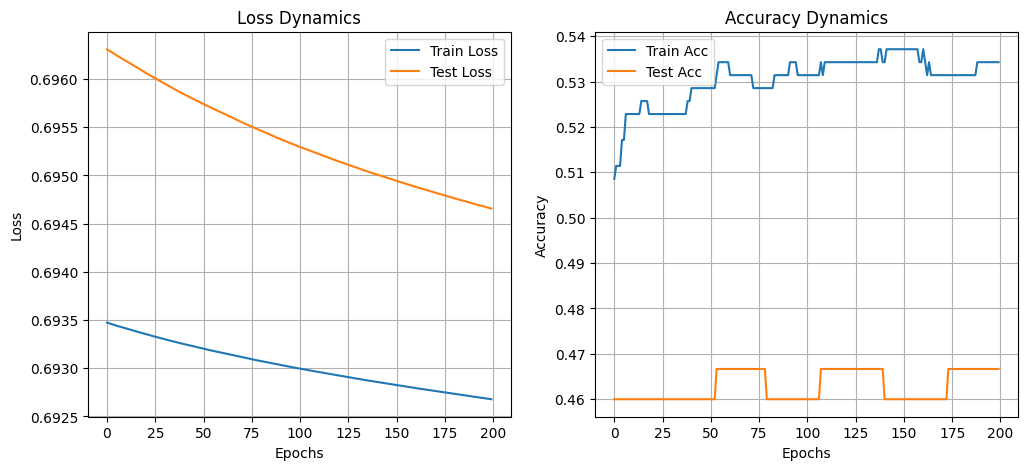

############################################################
############################################################
########## For learning_rate = 0.01 ##########
Starting training for 200 epochs...
Epoch 20/200 | Train Loss: 0.6932 Acc: 0.52 | Test Loss: 0.6982 Acc: 0.49
Epoch 40/200 | Train Loss: 0.6914 Acc: 0.53 | Test Loss: 0.6950 Acc: 0.49
Epoch 60/200 | Train Loss: 0.6901 Acc: 0.54 | Test Loss: 0.6928 Acc: 0.51
Epoch 80/200 | Train Loss: 0.6887 Acc: 0.58 | Test Loss: 0.6909 Acc: 0.55
Epoch 100/200 | Train Loss: 0.6869 Acc: 0.59 | Test Loss: 0.6887 Acc: 0.57
Epoch 120/200 | Train Loss: 0.6845 Acc: 0.65 | Test Loss: 0.6861 Acc: 0.63
Epoch 140/200 | Train Loss: 0.6811 Acc: 0.74 | Test Loss: 0.6825 Acc: 0.75
Epoch 160/200 | Train Loss: 0.6765 Acc: 0.81 | Test Loss: 0.6775 Acc: 0.82
Epoch 180/200 | Train Loss: 0.6699 Acc: 0.84 | Test Loss: 0.6705 Acc: 0.85
Epoch 200/200 | Train Loss: 0.6608 Acc: 0.82 | Test Loss: 0.6608 Acc: 0.83


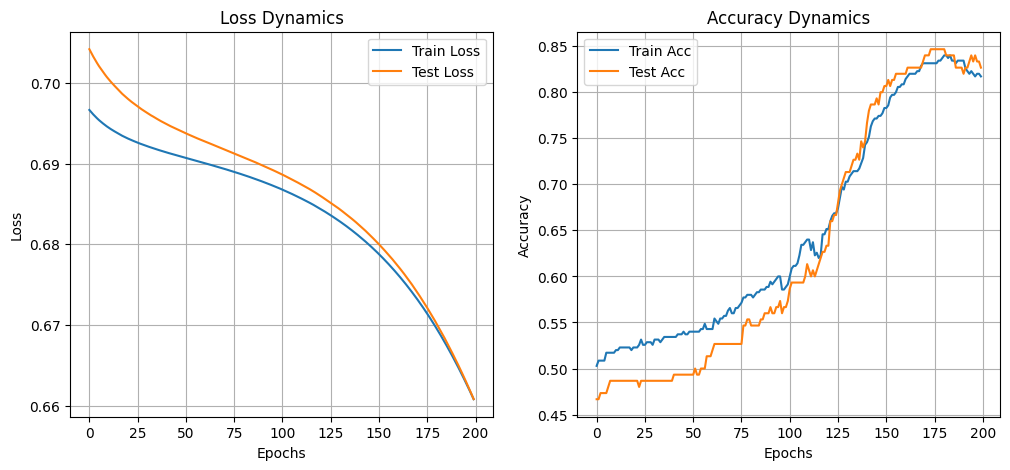

############################################################
############################################################
########## For learning_rate = 0.05 ##########
Starting training for 200 epochs...
Epoch 20/200 | Train Loss: 0.6924 Acc: 0.49 | Test Loss: 0.6940 Acc: 0.45
Epoch 40/200 | Train Loss: 0.6903 Acc: 0.55 | Test Loss: 0.6926 Acc: 0.52
Epoch 60/200 | Train Loss: 0.6800 Acc: 0.57 | Test Loss: 0.6843 Acc: 0.53
Epoch 80/200 | Train Loss: 0.6338 Acc: 0.74 | Test Loss: 0.6433 Acc: 0.71
Epoch 100/200 | Train Loss: 0.5492 Acc: 0.81 | Test Loss: 0.5682 Acc: 0.76
Epoch 120/200 | Train Loss: 0.4785 Acc: 0.82 | Test Loss: 0.5017 Acc: 0.79
Epoch 140/200 | Train Loss: 0.2999 Acc: 0.99 | Test Loss: 0.3116 Acc: 1.00
Epoch 160/200 | Train Loss: 0.1786 Acc: 1.00 | Test Loss: 0.1855 Acc: 1.00
Epoch 180/200 | Train Loss: 0.1238 Acc: 1.00 | Test Loss: 0.1294 Acc: 1.00
Epoch 200/200 | Train Loss: 0.0950 Acc: 1.00 | Test Loss: 0.0997 Acc: 1.00


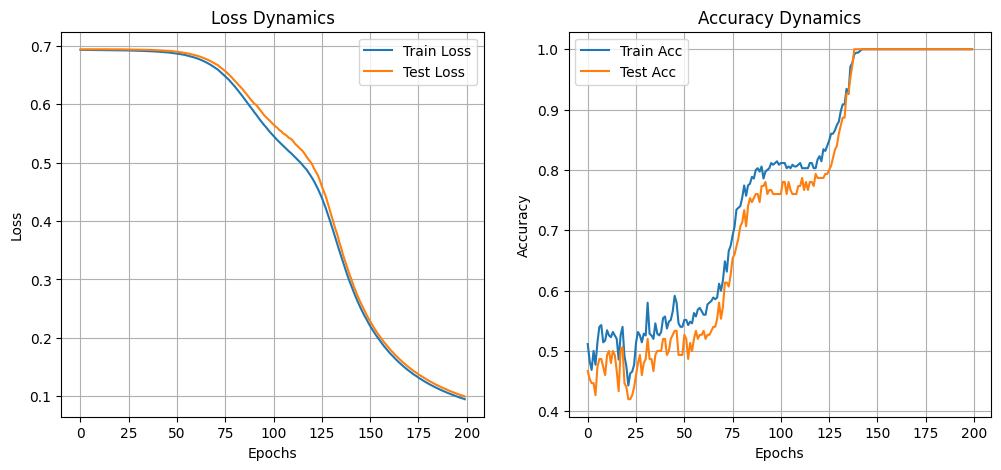

############################################################
############################################################
########## For learning_rate = 0.1 ##########
Starting training for 200 epochs...
Epoch 20/200 | Train Loss: 0.6815 Acc: 0.56 | Test Loss: 0.6840 Acc: 0.53
Epoch 40/200 | Train Loss: 0.5591 Acc: 0.80 | Test Loss: 0.5602 Acc: 0.79
Epoch 60/200 | Train Loss: 0.3010 Acc: 1.00 | Test Loss: 0.2963 Acc: 1.00
Epoch 80/200 | Train Loss: 0.1309 Acc: 1.00 | Test Loss: 0.1212 Acc: 1.00
Epoch 100/200 | Train Loss: 0.0832 Acc: 1.00 | Test Loss: 0.0718 Acc: 1.00
Epoch 120/200 | Train Loss: 0.0617 Acc: 1.00 | Test Loss: 0.0523 Acc: 1.00
Epoch 140/200 | Train Loss: 0.0502 Acc: 1.00 | Test Loss: 0.0415 Acc: 1.00
Epoch 160/200 | Train Loss: 0.0429 Acc: 1.00 | Test Loss: 0.0351 Acc: 1.00
Epoch 180/200 | Train Loss: 0.0378 Acc: 1.00 | Test Loss: 0.0299 Acc: 1.00
Epoch 200/200 | Train Loss: 0.0340 Acc: 1.00 | Test Loss: 0.0265 Acc: 1.00


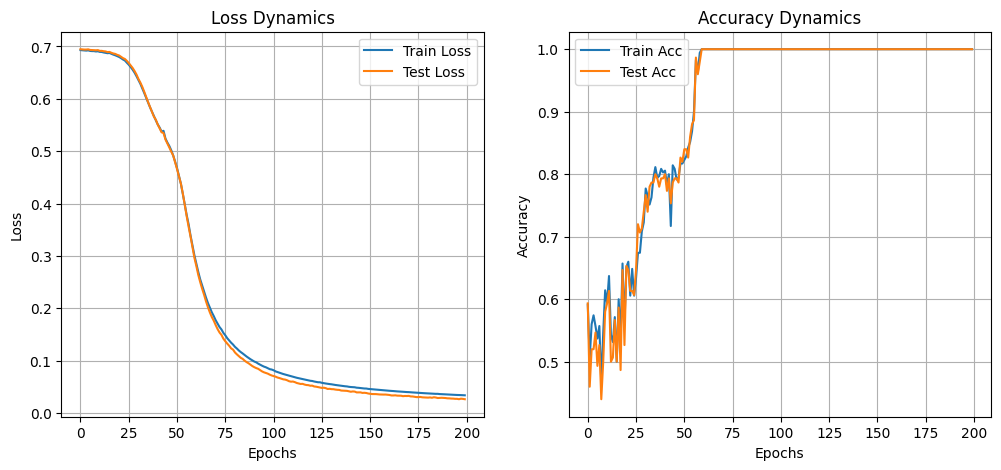

############################################################
############################################################
########## For learning_rate = 1.0 ##########
Starting training for 200 epochs...
Epoch 20/200 | Train Loss: 0.7166 Acc: 0.50 | Test Loss: 0.7169 Acc: 0.50
Epoch 40/200 | Train Loss: 0.7115 Acc: 0.50 | Test Loss: 0.7115 Acc: 0.50
Epoch 60/200 | Train Loss: 0.7004 Acc: 0.50 | Test Loss: 0.7004 Acc: 0.50
Epoch 80/200 | Train Loss: 0.6931 Acc: 0.50 | Test Loss: 0.6931 Acc: 0.50
Epoch 100/200 | Train Loss: 0.6932 Acc: 0.50 | Test Loss: 0.6932 Acc: 0.50
Epoch 120/200 | Train Loss: 0.7000 Acc: 0.50 | Test Loss: 0.7000 Acc: 0.50
Epoch 140/200 | Train Loss: 0.7153 Acc: 0.50 | Test Loss: 0.7153 Acc: 0.50
Epoch 160/200 | Train Loss: 0.6933 Acc: 0.50 | Test Loss: 0.6933 Acc: 0.50
Epoch 180/200 | Train Loss: 0.6974 Acc: 0.50 | Test Loss: 0.6974 Acc: 0.50
Epoch 200/200 | Train Loss: 0.6939 Acc: 0.50 | Test Loss: 0.6939 Acc: 0.50


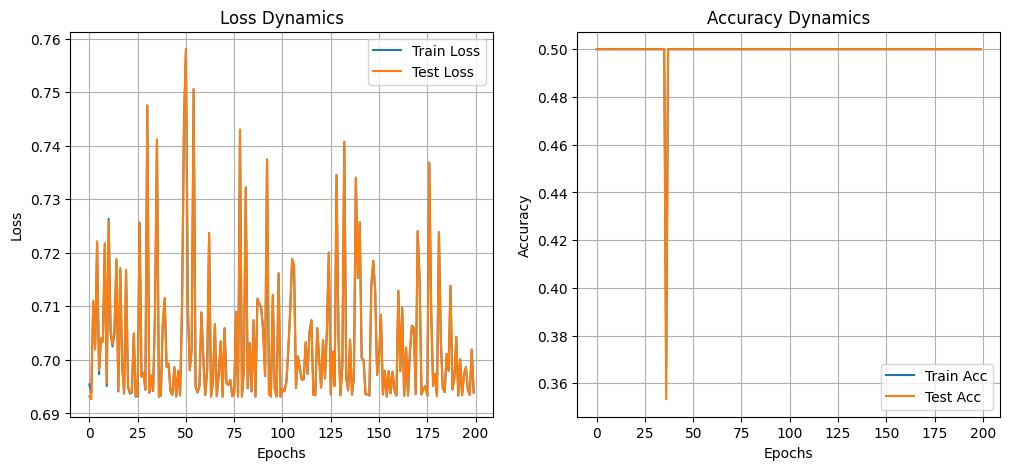

############################################################


In [ ]:
######## Fixed parameters ########
nx = 2    # Input features
nh = 6  # Hidden neurons
ny = 2    # Output classes
n_epochs = 200
batch_size = 16

# Unfixed parameter
learning_rates = [0.001, 0.01, 0.05, 0.1, 1.0]#(eta)

for eta_i in learning_rates :
  print("############################################################")
  print(f"########## For learning_rate = {eta_i} ##########")
  global_learning_alg(nx,nh,ny,eta_i,n_epochs,batch_size )
  print("############################################################")


**Learning Rate $\eta = 0.001$ and $\eta = 0.01$ (Too Small)**
* The accuracy increases very slowly (reaching only $\approx 0.55 - 0.60$) and the loss decreases linearly without curving down efficiently.
* The step size is **too small**. It would eventually reach the minimum, but it requires far more than 200 epochs to do so.

**2. Learning Rate $\eta = 0.05$ and $\eta = 0.1$ (Optimal)**
* The loss drops with a nice curve, and accuracy reaches **100%** ($1.00$).
* Now about the convergence :
    * With $\eta = 0.05$, convergence is stable and reaches 100% around epoch 130.
    * With $\eta = 0.1$, convergence is even faster, reaching 100% around **epoch 70** without overshooting. The steps are large enough to move quickly but small enough to stay stable.

**Learning Rate $\eta = 1.0$ (Too Large)**
* The accuracy is completely stuck at $0.50$ and the loss oscillates or remains high.
* The step size is **too huge**. The model "overshoots" the minimum with every update, bouncing back and forth across the valley without ever being able to settle down at the bottom.

Therefore $\eta = 0.1$ looks to be the optimal choice.

Here are our best parameters we found :    
* $n_h=6$
* batch_size $= 16$
* $\eta = 0.1$

### 2.2 Simplification of the backward pass with torch.autograd

PyTorch provides an automatic differentiation mechanism (autograd) available on all tensors. By default, on a tensor, this functionality is disabled. To activate it, you must put requires_grad to True ,

i.e. when creating the tensor ( torch.tensor (data, requires_grad = True)) or define the flag then (x.requires_grad = True).



To use autograd, we do loss.backward () , here on the tensor named loss , and autograd then
computes the derivative of loss with respect to all tensors which produced the loss tensor.

The gradients of all leaf tensors (those which are not the result of calculations of other tensors) are stored in the grad attribute of these tensors, for example W. grad if W is a leaf tensor. Concretely, in our
code, we must:

In [ ]:
def sgd_V2(params, eta):
    """
    Updates parameters using .grad and resets gradients to zero.
    MUST be done inside torch.no_grad() context.
    """
    with torch.no_grad():
        # Update Hidden Layer
        params["weight_h"] -= eta * params["weight_h"].grad
        params["bias_h"]   -= eta * params["bias_h"].grad

        # Update Output Layer
        params["weight_y"] -= eta * params["weight_y"].grad
        params["bias_y"]   -= eta * params["bias_y"].grad

        # Zero the gradients after update (otherwise they accumulate)
        params["weight_h"].grad.zero_()
        params["bias_h"].grad.zero_()
        params["weight_y"].grad.zero_()
        params["bias_y"].grad.zero_()

    return params

################## New version of algo with autograd ##################

def global_learning_alg_V2(nx, nh, ny, eta, n_epochs, batch_size):

    # Prepare Data (Same as before)
    X_np, Y_np = make_circles(n_samples=500, noise=0.05, factor=0.5, random_state=42)
    Y_onehot = np.zeros((Y_np.size, 2))
    Y_onehot[np.arange(Y_np.size), Y_np] = 1
    X_train_np, X_test_np, Y_train_np, Y_test_np = train_test_split(X_np, Y_onehot, test_size=0.3, random_state=42)

    X_train = torch.tensor(X_train_np).float()
    Y_train = torch.tensor(Y_train_np).float()
    X_test  = torch.tensor(X_test_np).float()
    Y_test  = torch.tensor(Y_test_np).float()

    N = X_train.shape[0]

    ########## Init Params with requiring grad  ##########
    params = init_params(nx, nh, ny)
    params["weight_h"].requires_grad = True
    params["bias_h"].requires_grad = True
    params["weight_y"].requires_grad = True
    params["bias_y"].requires_grad = True

    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

    print(f"Starting Autograd training for {n_epochs} epochs...")

    for i in range(n_epochs):
        indices = torch.randperm(N)
        X_shuffled = X_train[indices]
        Y_shuffled = Y_train[indices]

        for j in range(0, N, batch_size):
            end_idx = min(j + batch_size, N)
            Xbatch = X_shuffled[j:end_idx]
            Ybatch = Y_shuffled[j:end_idx]


            outputs, Y_hat_batch = forward(params, Xbatch)# Forward Pass

            ###### Compute Loss Update (using .grad attributes) #####
            L, _ = loss_accuracy(Y_hat_batch, Ybatch)

            ###### PyTorch computes gradients for all tensors with requires_grad=True ######
            L.backward()

            ###### SGD Update (using .grad attributes) #####
            params = sgd_V2(params, eta)

        ###### For history ######
        with torch.no_grad(): # Disable grad tracking for evaluation to save memory
            _, Y_hat_train = forward(params, X_train)
            _, Y_hat_test  = forward(params, X_test)
            tl, ta = loss_accuracy(Y_hat_train, Y_train)
            vl, va = loss_accuracy(Y_hat_test, Y_test)

        history['train_loss'].append(tl.item())
        history['train_acc'].append(ta.item())
        history['test_loss'].append(vl.item())
        history['test_acc'].append(va.item())

        if (i+1) % 20 == 0:
             print(f"Epoch {i+1}/{n_epochs} | Train Loss: {tl:.4f} | Test Acc: {va:.2f}")

    # Plotting
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train')
    plt.plot(history['test_loss'], label='Test')
    plt.title('Loss (Autograd)')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train')
    plt.plot(history['test_acc'], label='Test')
    plt.title('Accuracy (Autograd)')
    plt.legend()
    plt.show()

Starting Autograd training for 200 epochs...
Epoch 20/200 | Train Loss: 0.6928 | Test Acc: 0.47
Epoch 40/200 | Train Loss: 0.6916 | Test Acc: 0.51
Epoch 60/200 | Train Loss: 0.6881 | Test Acc: 0.53
Epoch 80/200 | Train Loss: 0.6702 | Test Acc: 0.73
Epoch 100/200 | Train Loss: 0.5979 | Test Acc: 0.81
Epoch 120/200 | Train Loss: 0.4844 | Test Acc: 0.84
Epoch 140/200 | Train Loss: 0.2935 | Test Acc: 1.00
Epoch 160/200 | Train Loss: 0.1768 | Test Acc: 1.00
Epoch 180/200 | Train Loss: 0.1231 | Test Acc: 1.00
Epoch 200/200 | Train Loss: 0.0949 | Test Acc: 1.00


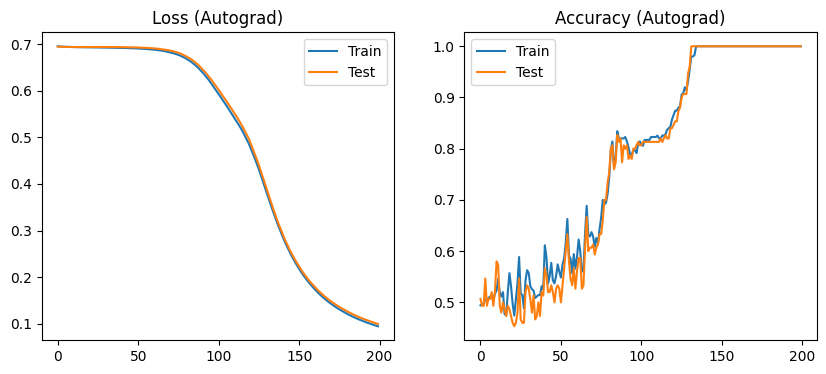

In [ ]:
global_learning_alg_V2(nx=2, nh=6, ny=2, eta=0.05, n_epochs=200, batch_size=16)

### 2.3 Simplification of the forward pass with torch.nn layers

PyTorch provides the standard layers of neural networks in the form of modules, making it possible to simplify and make more readable the writing of the network architecture.

**1. Implement the init_model (nx, nh, ny) function which will declare the model architecture and the loss and return them.**

In [ ]:
def init_model(nx, nh, ny):
  model = torch.nn.Sequential(
    torch.nn.Linear(nx, nh),
    torch.nn.Tanh(),
    torch.nn.Linear(nh, ny),
  )
  #CrossEntropyLoss
  loss = torch.nn.CrossEntropyLoss()

  return model, loss

**2. Replace the call to the function forward by a call to the model, and the computation of the loss in loss_accuracy by a call to the function of loss (new input parameter of the loss_accuracy
function)**



```
# Replace
Yhat, outs = forward(params, X)
# by
Yhat = model(X)
# The loss is then:
L = loss(Yhat, Y)
```



**3. The sgd function now takes the model as input. To make a gradient descent, we iterate on its parameters and apply our gradient descent**

In [ ]:
def sgd_v3(model, eta):
    """
    SGD update using model.parameters()
    """
    with torch.no_grad():
        for param in model.parameters():
            if param.grad is not None:
                param -= eta * param.grad
                param.grad.zero_() # Reset gradients
    return model

In [ ]:
def global_learning_alg_V3(nx, nh, ny, eta, n_epochs, batch_size):

    #Data Setup (Same as before)
    X_np, Y_np = make_circles(n_samples=500, noise=0.05, factor=0.5, random_state=42)
    Y_onehot = np.zeros((Y_np.size, 2))
    Y_onehot[np.arange(Y_np.size), Y_np] = 1
    X_train_np, X_test_np, Y_train_np, Y_test_np = train_test_split(X_np, Y_onehot, test_size=0.3, random_state=42)

    X_train = torch.tensor(X_train_np).float()
    X_test  = torch.tensor(X_test_np).float()

    # NOTE: CrossEntropyLoss usually expects class indices (1D tensor), NOT One-Hot
    # We convert Y from One-Hot back to indices: [0, 1, 0...] using argmax
    Y_train_indices = torch.tensor(Y_train_np).argmax(dim=1).long()
    Y_test_indices  = torch.tensor(Y_test_np).argmax(dim=1).long()

    N = X_train.shape[0]

    ######## Initialize Model & Loss ########
    model, loss_fn = init_model(nx, nh, ny)

    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

    print(f"Starting torch.nn training for {n_epochs} epochs...")

    for i in range(n_epochs):
        indices = torch.randperm(N)
        X_shuffled = X_train[indices]
        Y_shuffled = Y_train_indices[indices] # Use indices for shuffling

        for j in range(0, N, batch_size):
            end_idx = min(j + batch_size, N)
            Xbatch = X_shuffled[j:end_idx]
            Ybatch = Y_shuffled[j:end_idx]

            ########Forward ########
            output_logits = model(Xbatch)

            ######## Loss Calculation (Logits vs Class Indices) ########
            L = loss_fn(output_logits, Ybatch)

            # backward pass (Same as before)
            L.backward()

            ######## SGD V3 ########
            sgd_v3(model, eta)

        ######## History ########
        with torch.no_grad():
            # Train Stats
            train_logits = model(X_train)
            train_loss = loss_fn(train_logits, Y_train_indices).item()
            # Calculate accuracy manually since we have logits
            _, train_preds = torch.max(train_logits, 1)
            train_acc = (train_preds == Y_train_indices).float().mean().item()

            # Test Stats
            test_logits = model(X_test)
            test_loss = loss_fn(test_logits, Y_test_indices).item()
            _, test_preds = torch.max(test_logits, 1)
            test_acc = (test_preds == Y_test_indices).float().mean().item()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)

        if (i+1) % 20 == 0:
             print(f"Epoch {i+1}/{n_epochs} | Train Loss: {train_loss:.4f} | Test Acc: {test_acc:.2f}")

    # Plotting
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train')
    plt.plot(history['test_loss'], label='Test')
    plt.title('Loss (torch.nn)')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train')
    plt.plot(history['test_acc'], label='Test')
    plt.title('Accuracy (torch.nn)')
    plt.legend()
    plt.show()

Starting torch.nn training for 200 epochs...
Epoch 20/200 | Train Loss: 0.6848 | Test Acc: 0.53
Epoch 40/200 | Train Loss: 0.6604 | Test Acc: 0.58
Epoch 60/200 | Train Loss: 0.5620 | Test Acc: 0.83
Epoch 80/200 | Train Loss: 0.3759 | Test Acc: 1.00
Epoch 100/200 | Train Loss: 0.2194 | Test Acc: 1.00
Epoch 120/200 | Train Loss: 0.1434 | Test Acc: 1.00
Epoch 140/200 | Train Loss: 0.1053 | Test Acc: 1.00
Epoch 160/200 | Train Loss: 0.0834 | Test Acc: 1.00
Epoch 180/200 | Train Loss: 0.0694 | Test Acc: 1.00
Epoch 200/200 | Train Loss: 0.0597 | Test Acc: 1.00


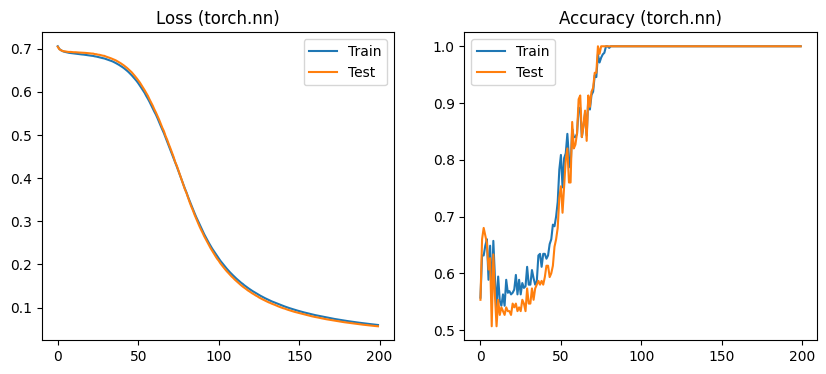

In [ ]:
global_learning_alg_V3(nx=2, nh=6, ny=2, eta=0.05, n_epochs=200, batch_size=16)

### 2.4 Simplification of the SGD with torch.optim

**1. Modify init_model by adding the learning rate as an input parameter, and make sure that it also returns the desired optimizer:**

In [ ]:
def init_model_V2(nx, nh, ny,eta):
  model = torch.nn.Sequential(
    torch.nn.Linear(nx, nh),
    torch.nn.Tanh(),
    torch.nn.Linear(nh, ny),
  )
  #CrossEntropyLoss
  loss = torch.nn.CrossEntropyLoss()

  optim = torch.optim.SGD(model.parameters(), lr=eta)
  return model, loss, optim

**2. We replace the sgd function with a call to optim.zero_grad () before doing the backward. Make a call to optim.step () after the backward.**

In [ ]:
def global_learning_alg_V4(nx, nh, ny, eta, n_epochs, batch_size):

    #Data  (Same as before)
    X_np, Y_np = make_circles(n_samples=500, noise=0.05, factor=0.5, random_state=42)
    Y_onehot = np.zeros((Y_np.size, 2))
    Y_onehot[np.arange(Y_np.size), Y_np] = 1
    X_train_np, X_test_np, Y_train_np, Y_test_np = train_test_split(X_np, Y_onehot, test_size=0.3, random_state=42)

    X_train = torch.tensor(X_train_np).float()
    X_test  = torch.tensor(X_test_np).float()

    Y_train_indices = torch.tensor(Y_train_np).argmax(dim=1).long()
    Y_test_indices  = torch.tensor(Y_test_np).argmax(dim=1).long()

    N = X_train.shape[0]

    ######## Initialize Model & Loss V2 ########
    model, loss_fn, optim = init_model_V2(nx, nh, ny, eta)

    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

    print(f"Starting torch.nn training for {n_epochs} epochs...")

    for i in range(n_epochs):
        indices = torch.randperm(N)
        X_shuffled = X_train[indices]
        Y_shuffled = Y_train_indices[indices] # Use indices for shuffling

        for j in range(0, N, batch_size):
            end_idx = min(j + batch_size, N)
            Xbatch = X_shuffled[j:end_idx]
            Ybatch = Y_shuffled[j:end_idx]


            output_logits = model(Xbatch)#forward


            L = loss_fn(output_logits, Ybatch)

            ######## automatically clears gradients for all parameters in the model ########
            optim.zero_grad()

            # backward pass (Same as before)
            L.backward()

            ########It automatically applies the SGD to all parameters ########
            optim.step()

        # History
        with torch.no_grad():
            # Train Stats
            train_logits = model(X_train)
            train_loss = loss_fn(train_logits, Y_train_indices).item()
            # Calculate accuracy manually since we have logits
            _, train_preds = torch.max(train_logits, 1)
            train_acc = (train_preds == Y_train_indices).float().mean().item()

            # Test Stats
            test_logits = model(X_test)
            test_loss = loss_fn(test_logits, Y_test_indices).item()
            _, test_preds = torch.max(test_logits, 1)
            test_acc = (test_preds == Y_test_indices).float().mean().item()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)

        if (i+1) % 20 == 0:
             print(f"Epoch {i+1}/{n_epochs} | Train Loss: {train_loss:.4f} | Test Acc: {test_acc:.2f}")

    # Plotting
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train')
    plt.plot(history['test_loss'], label='Test')
    plt.title('Loss (torch.nn)')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train')
    plt.plot(history['test_acc'], label='Test')
    plt.title('Accuracy (torch.nn)')
    plt.legend()
    plt.show()

Starting torch.nn training for 200 epochs...
Epoch 20/200 | Train Loss: 0.6678 | Test Acc: 0.54
Epoch 40/200 | Train Loss: 0.6054 | Test Acc: 0.76
Epoch 60/200 | Train Loss: 0.4927 | Test Acc: 0.83
Epoch 80/200 | Train Loss: 0.2972 | Test Acc: 1.00
Epoch 100/200 | Train Loss: 0.1742 | Test Acc: 1.00
Epoch 120/200 | Train Loss: 0.1203 | Test Acc: 1.00
Epoch 140/200 | Train Loss: 0.0922 | Test Acc: 1.00
Epoch 160/200 | Train Loss: 0.0754 | Test Acc: 1.00
Epoch 180/200 | Train Loss: 0.0643 | Test Acc: 1.00
Epoch 200/200 | Train Loss: 0.0565 | Test Acc: 1.00


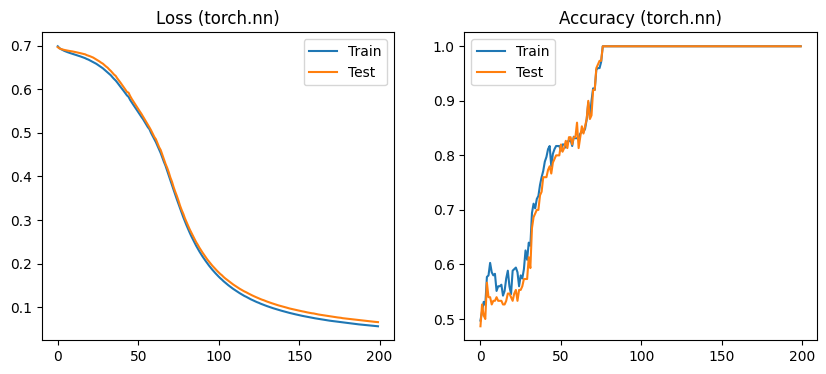

In [ ]:
global_learning_alg_V4(nx=2, nh=6, ny=2, eta=0.05, n_epochs=200, batch_size=16)

### 2.5 MNIST application

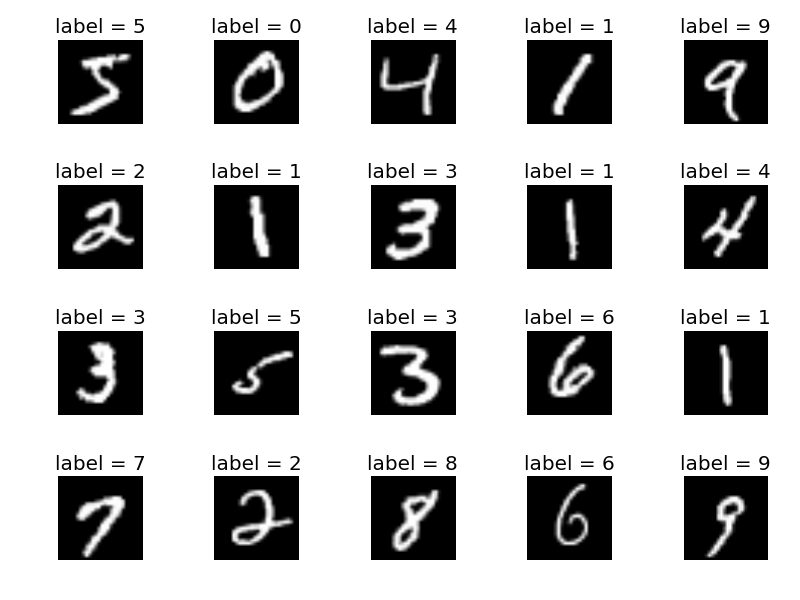

Finally, we can apply our code to the MNIST dataset. MNIST is a set of handwritten digit images, so there are 10 classes ($n_y = 10$). The images are 28 x 28 pixels, thus will be represented as a vector
of 784 values.

To use this dataset, use the **MNISTData** class which functions like the CirclesData class
without the dot grid and display functions.

In [ ]:
from sklearn.datasets import fetch_openml# to get bigger version with 784 inputs
#load_digits is has only 64 input of MNIST

def MNIST_alg(nx, nh, ny, eta, n_epochs, batch_size):

    print("Loading MNIST data... ")
    ############ Load Real MNIST (784 features) ############
    # as_frame=False returns numpy arrays directly
    X_np, Y_np = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)

    # Normalize Data
    # Neural Networks diverge if inputs are 0-255.
    # We need data that Scale to 0-1.
    X_np = X_np / 255.0

    # Handle Labels type
    # Y_np comes as strings '0', '1', etc. We convert to integers.
    Y_np = Y_np.astype(int)

    # Split Data
    X_train_np, X_test_np, Y_train_np, Y_test_np = train_test_split(X_np, Y_np, test_size=0.3, random_state=42)

    # To Tensors
    X_train = torch.tensor(X_train_np).float()
    X_test  = torch.tensor(X_test_np).float()

    # Direct to LongTensor (No need for One-Hot)
    Y_train_indices = torch.tensor(Y_train_np).long()
    Y_test_indices  = torch.tensor(Y_test_np).long()

    N = X_train.shape[0]

    ######## Initialize Model & Loss V2 ########
    model, loss_fn, optim = init_model_V2(nx, nh, ny, eta)

    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

    print(f"Starting MNIST training for {n_epochs} epochs...")

    for i in range(n_epochs):
        indices = torch.randperm(N)
        X_shuffled = X_train[indices]
        Y_shuffled = Y_train_indices[indices]

        for j in range(0, N, batch_size):
            end_idx = min(j + batch_size, N)
            Xbatch = X_shuffled[j:end_idx]
            Ybatch = Y_shuffled[j:end_idx]

            # Forward
            output_logits = model(Xbatch)
            L = loss_fn(output_logits, Ybatch)

            # Backward
            optim.zero_grad()
            L.backward()
            optim.step()

        ######## History ########
        # We wrap in no_grad to save memory.
        with torch.no_grad():
            # Test Stats (Only checking Test set to save time)
            test_logits = model(X_test)
            test_loss = loss_fn(test_logits, Y_test_indices).item()
            _, test_preds = torch.max(test_logits, 1)
            test_acc = (test_preds == Y_test_indices).float().mean().item()

            # Only checking a subset of train to speed up loop
            train_subset = X_train[:2000]
            train_label_subset = Y_train_indices[:2000]
            train_logits = model(train_subset)
            train_loss = loss_fn(train_logits, train_label_subset).item()
            _, train_preds = torch.max(train_logits, 1)
            train_acc = (train_preds == train_label_subset).float().mean().item()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)

        print(f"Epoch {i+1}/{n_epochs} | Train Loss: {train_loss:.4f} | Test Acc: {test_acc:.2f}")

    # Plotting
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train')
    plt.plot(history['test_loss'], label='Test')
    plt.title('Loss (MNIST)')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train')
    plt.plot(history['test_acc'], label='Test')
    plt.title('Accuracy (MNIST)')
    plt.legend()
    plt.show()


    ######## Visualize 4 Correct Predictions ########
    with torch.no_grad():
        # Get predictions for the entire test set
        logits = model(X_test)
        _, preds = torch.max(logits, 1)

    # Find indices where Prediction == Truth
    correct_mask = (preds == Y_test_indices)
    correct_indices = correct_mask.nonzero(as_tuple=True)[0]

    # Pick 4 random indices from the correct ones
    if len(correct_indices) >= 4:
        # randperm shuffles the indices, we take the first 4
        random_selection = correct_indices[torch.randperm(len(correct_indices))[:4]]

        plt.figure(figsize=(12, 3))
        for i, idx in enumerate(random_selection):
            plt.subplot(1, 4, i+1)

            # Reshape flat vector (784) back to image (28x28)
            image = X_test[idx].reshape(28, 28).numpy()

            plt.imshow(image, cmap='gray')
            plt.title(f"Pred: {preds[idx].item()} (True: {Y_test_indices[idx].item()})")
            plt.axis('off')

        plt.suptitle("Examples of Correct Predictions")
        plt.show()
    else:
        print("Not enough correct predictions to plot 4 images.")

Loading MNIST data... 
Starting MNIST training for 20 epochs...
Epoch 1/20 | Train Loss: 0.3219 | Test Acc: 0.92
Epoch 2/20 | Train Loss: 0.2582 | Test Acc: 0.93
Epoch 3/20 | Train Loss: 0.2164 | Test Acc: 0.94
Epoch 4/20 | Train Loss: 0.1897 | Test Acc: 0.95
Epoch 5/20 | Train Loss: 0.1611 | Test Acc: 0.95
Epoch 6/20 | Train Loss: 0.1460 | Test Acc: 0.96
Epoch 7/20 | Train Loss: 0.1323 | Test Acc: 0.96
Epoch 8/20 | Train Loss: 0.1212 | Test Acc: 0.96
Epoch 9/20 | Train Loss: 0.1109 | Test Acc: 0.96
Epoch 10/20 | Train Loss: 0.0999 | Test Acc: 0.96
Epoch 11/20 | Train Loss: 0.0934 | Test Acc: 0.96
Epoch 12/20 | Train Loss: 0.0848 | Test Acc: 0.97
Epoch 13/20 | Train Loss: 0.0826 | Test Acc: 0.97
Epoch 14/20 | Train Loss: 0.0741 | Test Acc: 0.97
Epoch 15/20 | Train Loss: 0.0733 | Test Acc: 0.97
Epoch 16/20 | Train Loss: 0.0673 | Test Acc: 0.97
Epoch 17/20 | Train Loss: 0.0638 | Test Acc: 0.97
Epoch 18/20 | Train Loss: 0.0573 | Test Acc: 0.97
Epoch 19/20 | Train Loss: 0.0580 | Test Acc: 

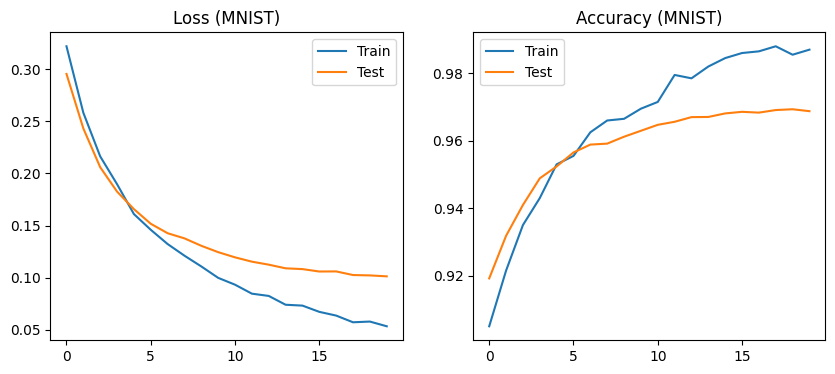

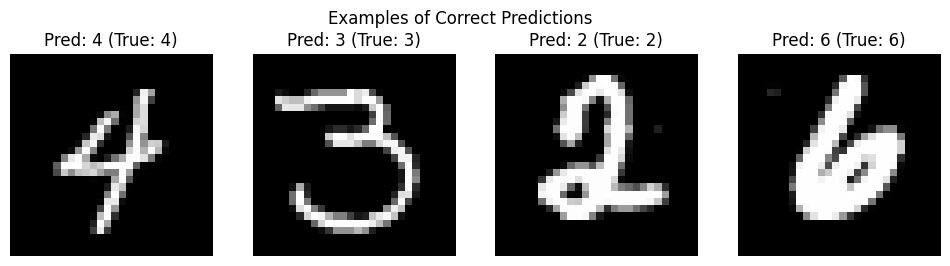

In [ ]:
nx_MNIST = 784   # Fixed: 28x28 pixels so vect of 784=28x28
nh_MNIST = 64    # 64 after trying different one
ny_MNIST = 10    # 10 classes (0-9)
eta_MNIST = 0.1  # Learning rate
epochs_MNIST = 20 # Reduced: MNIST converges faster than Circles
batch_size_MNIST = 64

MNIST_alg(nx_MNIST, nh_MNIST, ny_MNIST, eta_MNIST, epochs_MNIST, batch_size_MNIST)

### 2.6 Bonus: SVM

#### What is a Support Vector Machine (SVM)?

An SVM is a supervised machine learning algorithm that finds the optimal hyperplane in an $N$-dimensional space to distinctly classify data points into different classes.
    
The algorithm aims to maximize the margin, which is defined as the distance between the hyperplane and the nearest data points from either class (known as support vectors), ensuring better generalization.


For non-linearly separable data, SVMs use a kernel function $\phi(x)$ to map the input features into a higher-dimensional space where a linear separator can be found:
$$ K(x_i, x_j) = \phi(x_i) \cdot \phi(x_j) $$


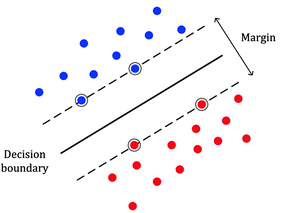

Lets try training an SVM on the Circle dataset.

To implement a Linear SVM using PyTorch, we rely on :

* **Linear Layer for the Model :**
An SVM is a linear classifier. We use a single fully connected layer without an activation function to represent the hyperplane:
$$f(x) = Wx + b$$

* **The Hinge Loss Function :**
Unlike Softmax/Cross-Entropy which outputs probabilities, SVM minimizes the **Hinge Loss** to enforce a margin. In PyTorch, this is provided by `torch.nn.MultiMarginLoss`:
$$L(x, y) = \sum_{i} \max(0, 1 - y_i \cdot f(x_i))$$

* **Margin Maximization (L2 Regularization):**
The core principle of SVM is to maximize the geometric margin, which is mathematically equivalent to minimizing the squared norm of the weights ($||W||^2$). We achieve this by adding **Weight Decay** (L2 penalty) to the SGD optimizer:
$$J(W) = \text{Loss} + \underbrace{\lambda ||W||^2}_{\text{weight\_decay}}$$


In [5]:
def init_SVM_model(nx, ny, eta):
    # just a Linear layer (Inputs -> Output Classes)
    model = torch.nn.Linear(nx, ny)

    # Loss for Multi-class
    loss = torch.nn.MultiMarginLoss()

    # Weight Decay acts as the L2 Regularization to maximize margin
    optim = torch.optim.SGD(model.parameters(), lr=eta, weight_decay=0.01)

    return model, loss, optim

#### Visualizing the SVM Decision Boundary

Since our SVM was trained on **3-dimensional data** ($x, y, x^2+y^2$), we cannot simply plot a 2D line. To visualize the boundary back in the original 2D space, we use a **Meshgrid** approach:

1.  **Create a Grid:** We generate a dense grid of points $(x, y)$ covering the entire plot area.
2.  **Feature Engineering on the Grid:** Crucially, we must compute the 3rd feature (Radius $= x^2 + y^2$) for **every point on this grid**, just like we did for the training data.
3.  **Prediction:** The model predicts the class for every point in the grid based on these 3 features.
4.  **Contour Plot:** We use `plt.contourf` to color the background regions based on the model's predictions, revealing that the "linear" hyperplane in 3D corresponds to a **circular boundary** in 2D.

In [9]:
def plot_svm_boundary(model, X, Y):
    """
    Plots the decision boundary for the SVM with the custom kernel feature.
    """
    # Create a meshgrid covering the data range
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    # Flatten grid to (N, 2)
    grid_2d = np.c_[xx.ravel(), yy.ravel()]

    # IMPORTANT : Add the 3rd 'Radius' feature to the grid points
    # The model expects 3 inputs, so we must compute r = x^2 + y^2 for the grid too
    radius_feature = (grid_2d[:, 0]**2 + grid_2d[:, 1]**2).reshape(-1, 1)
    grid_3d = np.hstack((grid_2d, radius_feature))

    # Make predictions
    with torch.no_grad():
        inputs = torch.tensor(grid_3d).float()
        outputs = model(inputs)
        # SVM Prediction is the class with max score
        _, predicted = torch.max(outputs, 1)

    # Reshape for contour plot
    Z = predicted.reshape(xx.shape).numpy()

    # Plotting
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm) # The background regions
    plt.scatter(X[:, 0], X[:, 1], c=Y, cmap=plt.cm.coolwarm, edgecolors='k') # The real data
    plt.title("SVM Decision Boundary (with Radius Kernel)")
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.show()

The we create our global function for it.

Unlike the Neural Network which learns non-linearities via hidden layers, here we manually transform the input to 3D by adding the radius squared:
$$ \tilde{x} = [x_1, x_2, x_1^2 + x_2^2] $$
This allows a linear hyperplane to separate the concentric circles in the higher-dimensional space.

We replace the probabilistic Cross-Entropy Loss with the Multi-Margin Loss (Hinge Loss). This objective function focuses on maximizing the geometric margin between classes rather than minimizing the negative log-likelihood:
$$ L(x, y) = \sum_{j \neq y} \max(0, 1 - (f(x)_y - f(x)_j)) $$


Then the model is reduced to a single nn.Linear layer (no hidden neurons, $n_h=0$) with no activation function, effectively acting as a linear classifier on the augmented feature set.


In [15]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
def SVM_alg(nx, nh, ny, eta, n_epochs, batch_size):
    # Here we don't need 'nh' (hidden neurons) for a linear SVM

    ######## Data Setup ########
    X_np, Y_np = make_circles(n_samples=500, noise=0.05, factor=0.5, random_state=42)

    # Circles are not linearly separable in 2D.
    # We add a 3rd feature: Radius^2 = x^2 + y^2
    # This lifts the data into 3D where a plane can separate them
    radius_feature = (X_np[:, 0]**2 + X_np[:, 1]**2).reshape(-1, 1)
    X_np = np.hstack((X_np, radius_feature))

    # Update nx because we now have 3 features (x, y, radius)
    nx = 3

    # Split
    X_train_np, X_test_np, Y_train_np, Y_test_np = train_test_split(X_np, Y_np, test_size=0.3, random_state=42)

    # Convert to Tensors
    X_train = torch.tensor(X_train_np).float()
    X_test  = torch.tensor(X_test_np).float()

    # SVM uses Class Indices directly (0 or 1), NOT One-Hot
    Y_train = torch.tensor(Y_train_np).long()
    Y_test  = torch.tensor(Y_test_np).long()

    N = X_train.shape[0]

    ######## Initialize SVM ########
    model, loss_fn, optim = init_SVM_model(nx, ny, eta)

    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

    print(f"Starting SVM training for {n_epochs} epochs...")

    for i in range(n_epochs):
        indices = torch.randperm(N)
        X_shuffled = X_train[indices]
        Y_shuffled = Y_train[indices]

        for j in range(0, N, batch_size):
            end_idx = min(j + batch_size, N)
            Xbatch = X_shuffled[j:end_idx]
            Ybatch = Y_shuffled[j:end_idx]

            # Forward
            output = model(Xbatch)

            # Loss (Hinge)
            L = loss_fn(output, Ybatch)

            # Backward
            optim.zero_grad()
            L.backward()
            optim.step()

        # Monitoring
        with torch.no_grad():
            train_out = model(X_train)
            train_loss = loss_fn(train_out, Y_train).item()
            _, train_preds = torch.max(train_out, 1)
            train_acc = (train_preds == Y_train).float().mean().item()

            test_out = model(X_test)
            test_loss = loss_fn(test_out, Y_test).item()
            _, test_preds = torch.max(test_out, 1)
            test_acc = (test_preds == Y_test).float().mean().item()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)

        if (i+1) % 1 == 0:
             print(f"Epoch {i+1}/{n_epochs} | Train Loss: {train_loss:.4f} | Test Acc: {test_acc:.2f}")

    # Plotting
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train')
    plt.plot(history['test_loss'], label='Test')
    plt.title('Loss (SVM Hinge)')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train')
    plt.plot(history['test_acc'], label='Test')
    plt.title('Accuracy (SVM)')
    plt.legend()
    plt.show()

    print("Plotting Decision Boundary...")
    plot_svm_boundary(model, X_test.numpy(), Y_test.numpy())

Starting SVM training for 5 epochs...
Epoch 1/5 | Train Loss: 0.4729 | Test Acc: 0.69
Epoch 2/5 | Train Loss: 0.3273 | Test Acc: 0.58
Epoch 3/5 | Train Loss: 0.2503 | Test Acc: 0.93
Epoch 4/5 | Train Loss: 0.1855 | Test Acc: 1.00
Epoch 5/5 | Train Loss: 0.1225 | Test Acc: 1.00


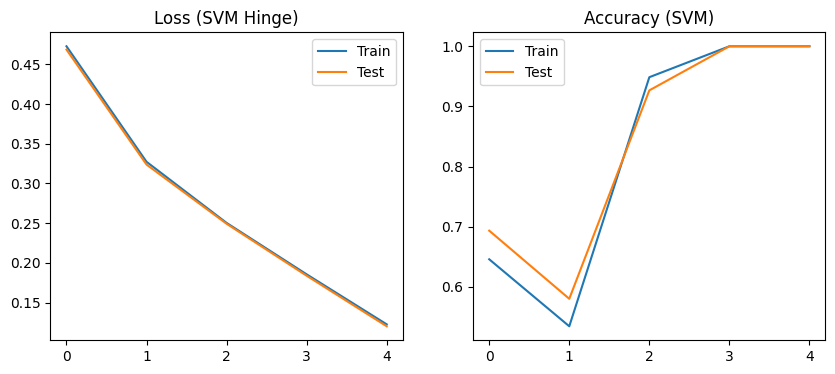

Plotting Decision Boundary...


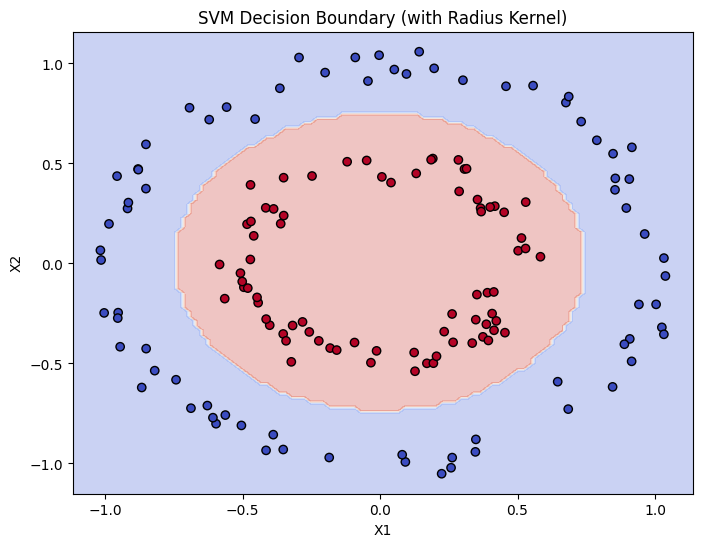

In [16]:
SVM_alg(nx=2, nh=0, ny=2, eta=0.1, n_epochs=5, batch_size=16)

Here we can see that the model converge really fast with only 5 epochs to reach 100% of accuracy and the loss function is almost a straight line.